In [1]:
"""
============================================================
STREAMFLIX CONTENT ANALYTICS
PHASE 2 - EXPLORATORY DATA ANALYSIS
Author : Sujal
============================================================
"""

import os
import logging
from datetime import datetime

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns",None)
pd.set_option("display.width",150)

os.makedirs("charts",exist_ok=True)
os.makedirs("logs",exist_ok=True)

logging.basicConfig(

    level=logging.INFO,

    format="%(asctime)s | %(levelname)s | %(message)s",

    handlers=[

        logging.FileHandler(
            f"logs/phase2_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"
        ),

        logging.StreamHandler()

    ]

)

logger=logging.getLogger(__name__)

logger.info("="*80)
logger.info("PHASE 2 STARTED")
logger.info("="*80)

2026-07-21 21:45:58,596 | INFO | ================================================================================
2026-07-21 21:45:58,598 | INFO | PHASE 2 STARTED
2026-07-21 21:45:58,600 | INFO | ================================================================================


In [2]:
subscribers=pd.read_csv(
    "data/cleaned/subscribers_clean.csv",
    parse_dates=["signup_date","churn_date"]
)

titles=pd.read_csv(
    "data/cleaned/titles_clean.csv",
    parse_dates=["date_added","license_expiry"]
)

watch_history=pd.read_csv(
    "data/cleaned/watch_history_clean.csv",
    parse_dates=["watch_date"]
)

ratings=pd.read_csv(
    "data/cleaned/ratings_clean.csv",
    parse_dates=["rating_date"]
)

reviews=pd.read_csv(
    "data/cleaned/reviews_clean.csv",
    parse_dates=["review_date"]
)

watchlist=pd.read_csv(
    "data/cleaned/watchlist_clean.csv",
    parse_dates=["added_date"]
)

logger.info("All cleaned datasets loaded.")

2026-07-21 21:46:01,856 | INFO | All cleaned datasets loaded.


In [3]:
datasets={

"Subscribers":subscribers,

"Titles":titles,

"Watch History":watch_history,

"Ratings":ratings,

"Reviews":reviews,

"Watchlist":watchlist

}

for name,df in datasets.items():

    logger.info(f"{name} Shape : {df.shape}")

    print(name)

    print(df.shape)

2026-07-21 21:46:01,874 | INFO | Subscribers Shape : (15000, 14)
2026-07-21 21:46:01,877 | INFO | Titles Shape : (9000, 21)
2026-07-21 21:46:01,878 | INFO | Watch History Shape : (650000, 12)
2026-07-21 21:46:01,880 | INFO | Ratings Shape : (130000, 5)
2026-07-21 21:46:01,881 | INFO | Reviews Shape : (110000, 7)
2026-07-21 21:46:01,883 | INFO | Watchlist Shape : (65000, 5)


Subscribers
(15000, 14)
Titles
(9000, 21)
Watch History
(650000, 12)
Ratings
(130000, 5)
Reviews
(110000, 7)
Watchlist
(65000, 5)


In [4]:
eda=watch_history.merge(

    subscribers,

    on="subscriber_id",

    how="left"

)

eda=eda.merge(

    titles,

    on="title_id",

    how="left"

)

logger.info("Merged Dataset Created")

print(eda.shape)

2026-07-21 21:46:03,028 | INFO | Merged Dataset Created


(650000, 45)


In [5]:
eda["Watch Hours"]=eda["watch_duration_min"]/60

eda["Year"]=eda["watch_date"].dt.year

eda["Month"]=eda["watch_date"].dt.month

eda["Month Name"]=eda["watch_date"].dt.strftime("%b")

eda["Quarter"]=eda["watch_date"].dt.quarter

eda["Weekday"]=eda["watch_date"].dt.day_name()

eda["Age Group"]=pd.cut(

    eda["age"],

    bins=[10,18,25,35,45,55,65,100],

    labels=[
        "13-18",
        "19-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ]
)

logger.info("Feature Engineering Completed")

2026-07-21 21:46:07,922 | INFO | Feature Engineering Completed


In [6]:
print()
print("="*80)
print("EDA SUMMARY")
print("="*80)
print(eda.describe(include="all").T)


EDA SUMMARY
                           count unique                                                top    freq                           mean  \
watch_id                650000.0    NaN                                                NaN     NaN                       325000.5   
subscriber_id             650000  14998                                          SUB107911    5989                            NaN   
title_id                  650000   9000                                          TTL205962    4436                            NaN   
watch_date                650000    NaN                                                NaN     NaN  2025-11-18 08:03:03.212308224   
device                    650000      6                                           Smart TV  221446                            NaN   
region_x                  650000      9                                      North America  197412                            NaN   
content_duration_min_x  650000.0    NaN                 

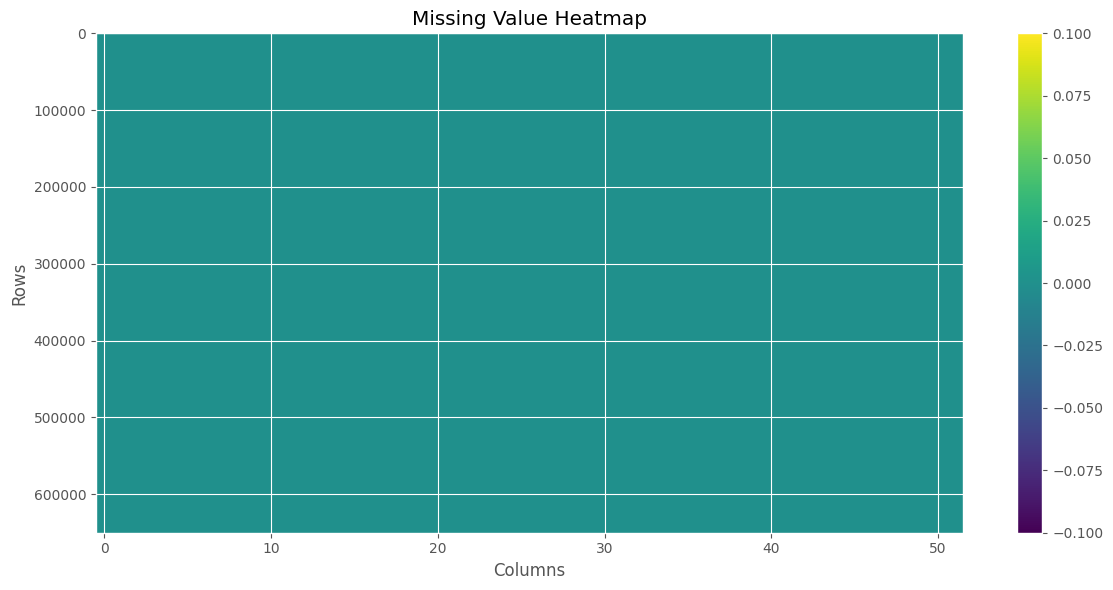


===== Insight: Missing Value Heatmap =====
Total Records : 650000
Total Columns : 52
Total Missing Values : 0

Missing Values by Column:
- watch_id: 0 missing values (0.00%)
- subscriber_id: 0 missing values (0.00%)
- title_id: 0 missing values (0.00%)
- watch_date: 0 missing values (0.00%)
- device: 0 missing values (0.00%)
- region_x: 0 missing values (0.00%)
- content_duration_min_x: 0 missing values (0.00%)
- watch_duration_min: 0 missing values (0.00%)
- completion_pct: 0 missing values (0.00%)
- completed: 0 missing values (0.00%)
- Calculated Completion: 0 missing values (0.00%)
- Difference: 0 missing values (0.00%)
- signup_date: 0 missing values (0.00%)
- country_x: 0 missing values (0.00%)
- region_y: 0 missing values (0.00%)
- age: 0 missing values (0.00%)
- gender: 0 missing values (0.00%)
- plan_type: 0 missing values (0.00%)
- monthly_price_usd: 0 missing values (0.00%)
- household_size: 0 missing values (0.00%)
- primary_device: 0 missing values (0.00%)
- payment_metho

In [7]:
plt.figure(figsize=(12,6))

plt.imshow(

    eda.isnull(),

    aspect="auto",

    interpolation="nearest"

)

plt.title("Missing Value Heatmap")

plt.xlabel("Columns")

plt.ylabel("Rows")

plt.colorbar()

plt.tight_layout()

plt.savefig(

    "charts/missing_heatmap.png",

    dpi=300

)

plt.show()

print("\n===== Insight: Missing Value Heatmap =====")

missing = eda.isnull().sum()
missing_percent = (missing / len(eda)) * 100

total_missing = missing.sum()

print(f"Total Records : {len(eda)}")
print(f"Total Columns : {eda.shape[1]}")
print(f"Total Missing Values : {total_missing}")

print("\nMissing Values by Column:")

for col in eda.columns:
    print(
        f"- {col}: {missing[col]} missing values "
        f"({missing_percent[col]:.2f}%)"
    )

highest_missing = missing.idxmax()
highest_count = missing.max()
highest_percent = missing_percent.max()

print(f"\nColumn with Most Missing Values : {highest_missing}")
print(f"Missing Values : {highest_count} ({highest_percent:.2f}%)")

complete_columns = missing[missing == 0]

print(f"\nColumns with No Missing Values : {len(complete_columns)}")

if len(complete_columns) > 0:
    for col in complete_columns.index:
        print(f"- {col}")

print("\nInsight:")
print("- The missing value heatmap visually highlights the distribution of missing data across all records and features.")
print(f"- '{highest_missing}' contains the highest number of missing values ({highest_count}), accounting for {highest_percent:.2f}% of the dataset.")
print("- Columns with no missing values are complete and can be used directly for analysis and modeling.")
print("- Features containing missing values should be handled using appropriate techniques such as imputation, deletion, or data validation.")
print("- Proper treatment of missing data improves data quality, enhances model accuracy, and ensures reliable business insights.")

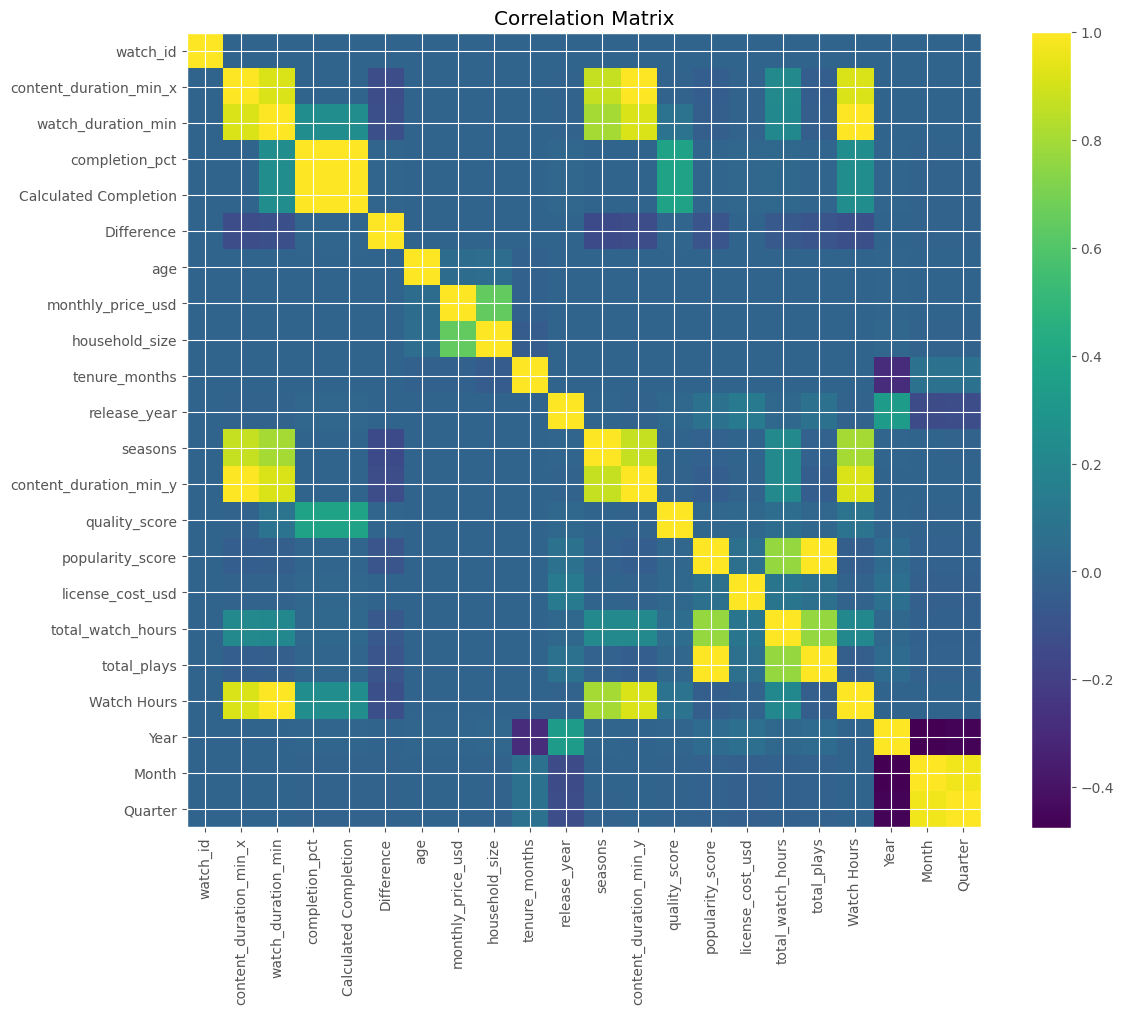


===== Insight: Correlation Matrix =====
Total Numeric Features : 22

Strongest Positive Correlation:
content_duration_min_x ↔ content_duration_min_y : 1.000

Strongest Negative Correlation:
Year ↔ Month : -0.475

Highly Correlated Feature Pairs (|Correlation| ≥ 0.70):
- content_duration_min_x ↔ watch_duration_min : 0.915
- content_duration_min_x ↔ seasons : 0.873
- content_duration_min_x ↔ content_duration_min_y : 1.000
- content_duration_min_x ↔ Watch Hours : 0.915
- watch_duration_min ↔ seasons : 0.801
- watch_duration_min ↔ content_duration_min_y : 0.915
- watch_duration_min ↔ Watch Hours : 1.000
- completion_pct ↔ Calculated Completion : 1.000
- seasons ↔ content_duration_min_y : 0.873
- seasons ↔ Watch Hours : 0.801
- content_duration_min_y ↔ Watch Hours : 0.915
- popularity_score ↔ total_watch_hours : 0.767
- popularity_score ↔ total_plays : 1.000
- total_watch_hours ↔ total_plays : 0.766
- Month ↔ Quarter : 0.969

Insight:
- The correlation matrix illustrates the strength and d

In [8]:
numeric=eda.select_dtypes(include=np.number)

corr=numeric.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.xticks(

    range(len(corr.columns)),

    corr.columns,

    rotation=90

)

plt.yticks(

    range(len(corr.columns)),

    corr.columns

)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.savefig(

    "charts/correlation_matrix.png",

    dpi=300

)

plt.show()

print("\n===== Insight: Correlation Matrix =====")

print(f"Total Numeric Features : {len(corr.columns)}")

# Ignore self-correlation (1.0)
corr_matrix = corr.copy()

np.fill_diagonal(corr_matrix.values, np.nan)

# Strongest positive correlation
max_pair = corr_matrix.unstack().idxmax()
max_value = corr_matrix.unstack().max()

# Strongest negative correlation
min_pair = corr_matrix.unstack().idxmin()
min_value = corr_matrix.unstack().min()

print("\nStrongest Positive Correlation:")
print(f"{max_pair[0]} ↔ {max_pair[1]} : {max_value:.3f}")

print("\nStrongest Negative Correlation:")
print(f"{min_pair[0]} ↔ {min_pair[1]} : {min_value:.3f}")

print("\nHighly Correlated Feature Pairs (|Correlation| ≥ 0.70):")

found = False

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]
        if abs(value) >= 0.70:
            print(f"- {corr.columns[i]} ↔ {corr.columns[j]} : {value:.3f}")
            found = True

if not found:
    print("No strongly correlated feature pairs found.")

print("\nInsight:")
print("- The correlation matrix illustrates the strength and direction of relationships between numerical variables.")
print(f"- The strongest positive relationship is between '{max_pair[0]}' and '{max_pair[1]}' with a correlation coefficient of {max_value:.3f}.")
print(f"- The strongest negative relationship is between '{min_pair[0]}' and '{min_pair[1]}' with a correlation coefficient of {min_value:.3f}.")
print("- Highly correlated variables may indicate redundancy and can be considered during feature selection for machine learning models.")
print("- Features with weak correlations provide independent information and may improve predictive model performance when combined.")
print("- Correlation analysis helps identify important relationships, detect multicollinearity, and support data-driven decision-making.")

In [9]:
# -------------------------------------------------------
# SAVE CHART FUNCTION
# -------------------------------------------------------

def save_chart(filename):

    plt.tight_layout()

    plt.savefig(

        f"charts/{filename}",

        dpi=300,

        bbox_inches="tight"

    )

    logger.info(f"{filename} saved successfully.")

    plt.show()

    plt.close()

C:\Users\Sujal\AppData\Local\Temp\ipykernel_22632\2043440961.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(
2026-07-21 21:46:34,496 | INFO | 01_Monthly_Viewing_Sessions.png saved successfully.


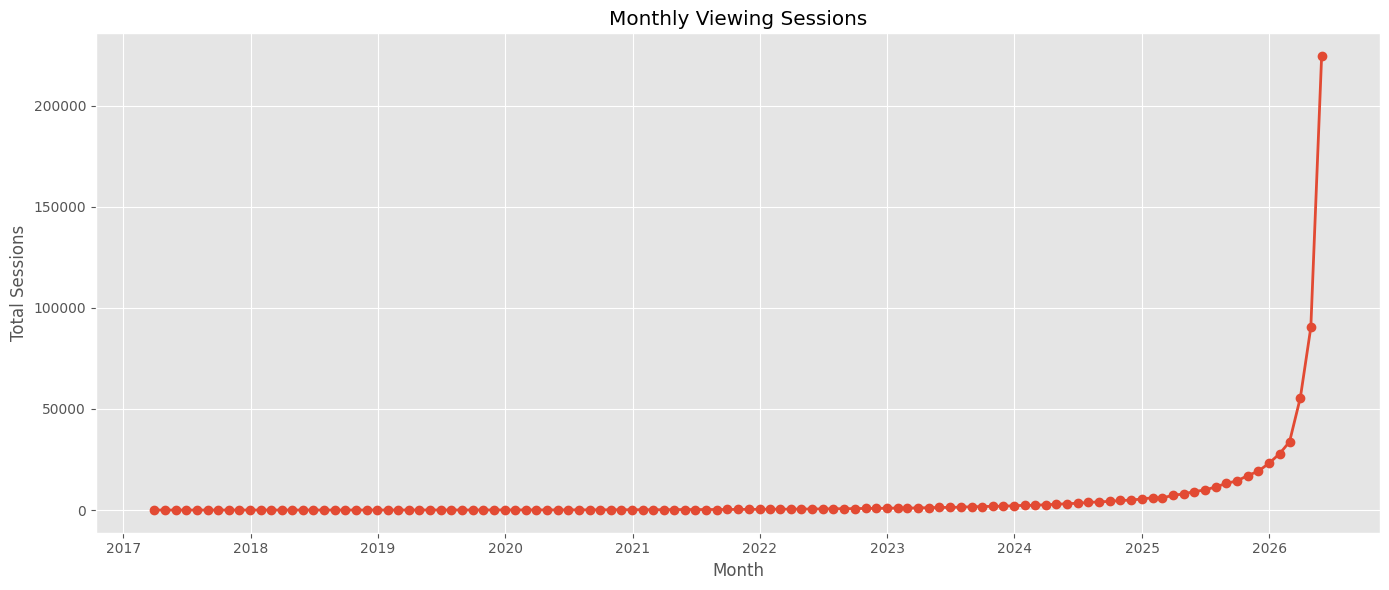

watch_date
2026-01-31     27970
2026-02-28     33795
2026-03-31     55665
2026-04-30     90383
2026-05-31    224696
Freq: ME, dtype: int64

===== Insight: Monthly Viewing Sessions =====
Total Months Analyzed : 111
Total Viewing Sessions : 650000
Average Monthly Sessions : 5855.86

Highest Viewing Month : May 2026
Viewing Sessions : 224696

Lowest Viewing Month : June 2017
Viewing Sessions : 0

Monthly Viewing Sessions:
- Mar 2017: 1
- Apr 2017: 1
- May 2017: 1
- Jun 2017: 0
- Jul 2017: 1
- Aug 2017: 0
- Sep 2017: 2
- Oct 2017: 1
- Nov 2017: 6
- Dec 2017: 1
- Jan 2018: 4
- Feb 2018: 3
- Mar 2018: 1
- Apr 2018: 6
- May 2018: 8
- Jun 2018: 9
- Jul 2018: 7
- Aug 2018: 5
- Sep 2018: 7
- Oct 2018: 16
- Nov 2018: 13
- Dec 2018: 17
- Jan 2019: 13
- Feb 2019: 14
- Mar 2019: 17
- Apr 2019: 19
- May 2019: 36
- Jun 2019: 16
- Jul 2019: 23
- Aug 2019: 32
- Sep 2019: 25
- Oct 2019: 35
- Nov 2019: 50
- Dec 2019: 50
- Jan 2020: 57
- Feb 2020: 60
- Mar 2020: 71
- Apr 2020: 65
- May 2020: 73
- Jun 2020:

In [10]:
# -------------------------------------------------------
# MONTHLY VIEWING VOLUME
# -------------------------------------------------------

monthly_views=(

    eda

    .groupby(

        pd.Grouper(

            key="watch_date",

            freq="M"

        )

    )

    .size()

)

plt.figure(figsize=(14,6))

plt.plot(

    monthly_views.index,

    monthly_views.values,

    marker="o",

    linewidth=2

)

plt.title("Monthly Viewing Sessions")

plt.xlabel("Month")

plt.ylabel("Total Sessions")

plt.grid(True)

save_chart("01_Monthly_Viewing_Sessions.png")

print(monthly_views.tail())

print("\n===== Insight: Monthly Viewing Sessions =====")

print(f"Total Months Analyzed : {len(monthly_views)}")
print(f"Total Viewing Sessions : {monthly_views.sum()}")
print(f"Average Monthly Sessions : {monthly_views.mean():.2f}")

highest_month = monthly_views.idxmax()
highest_sessions = monthly_views.max()

lowest_month = monthly_views.idxmin()
lowest_sessions = monthly_views.min()

print(f"\nHighest Viewing Month : {highest_month.strftime('%B %Y')}")
print(f"Viewing Sessions : {highest_sessions}")

print(f"\nLowest Viewing Month : {lowest_month.strftime('%B %Y')}")
print(f"Viewing Sessions : {lowest_sessions}")

print("\nMonthly Viewing Sessions:")
for month, sessions in monthly_views.items():
    print(f"- {month.strftime('%b %Y')}: {sessions}")

growth = monthly_views.pct_change() * 100
avg_growth = growth.dropna().mean()

print(f"\nAverage Month-over-Month Growth : {avg_growth:.2f}%")

print("\nInsight:")
print(f"- {highest_month.strftime('%B %Y')} recorded the highest number of viewing sessions ({highest_sessions}), indicating peak user engagement.")
print(f"- {lowest_month.strftime('%B %Y')} had the fewest viewing sessions ({lowest_sessions}), representing the lowest activity period.")
print("- The monthly viewing trend helps identify seasonal viewing patterns and fluctuations in platform usage.")
print("- Consistent growth in monthly sessions suggests increasing subscriber engagement and successful content strategies.")
print("- Monitoring viewing sessions over time supports demand forecasting, content release planning, and business decision-making.")

print("\nLast 5 Months:")
print(monthly_views.tail())

C:\Users\Sujal\AppData\Local\Temp\ipykernel_22632\378173311.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(
2026-07-21 21:46:37,503 | INFO | 02_Monthly_Watch_Hours.png saved successfully.


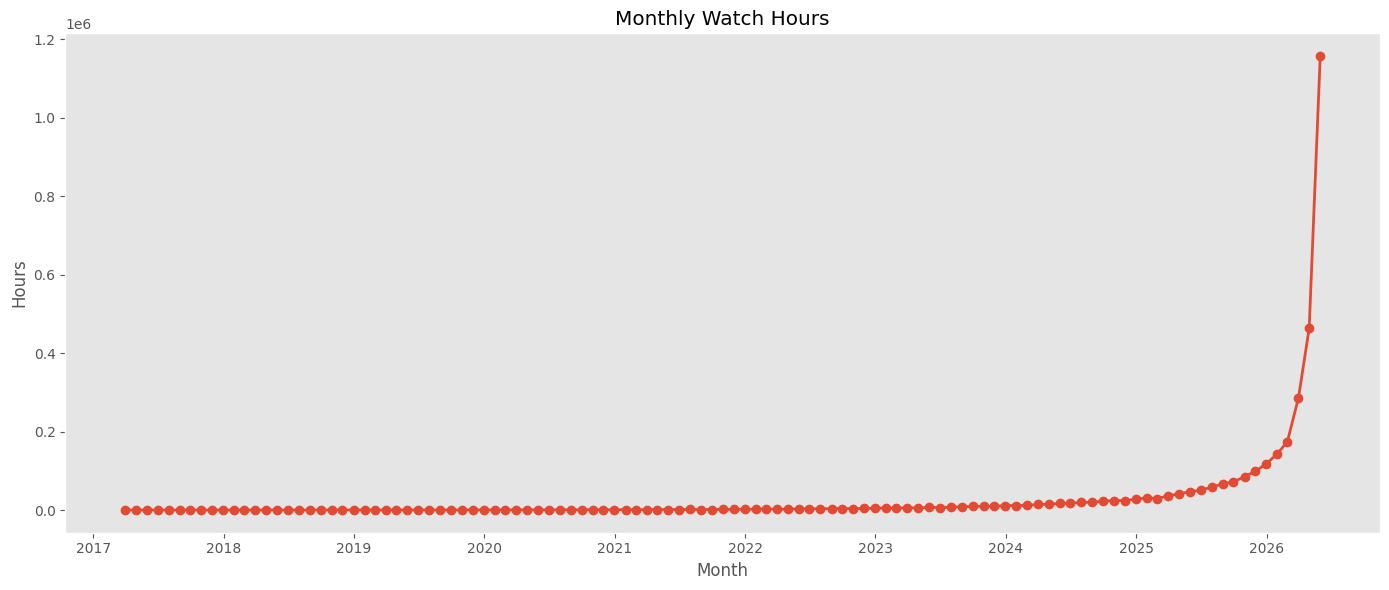


===== Insight: Monthly Watch Hours =====
Total Months Analyzed : 111
Total Watch Hours : 3333467.73
Average Monthly Watch Hours : 30031.24

Highest Watch Hours Month : May 2026
Watch Hours : 1157785.90

Lowest Watch Hours Month : June 2017
Watch Hours : 0.00

Monthly Watch Hours:
- Mar 2017: 4.77 hours
- Apr 2017: 4.40 hours
- May 2017: 14.42 hours
- Jun 2017: 0.00 hours
- Jul 2017: 1.41 hours
- Aug 2017: 0.00 hours
- Sep 2017: 2.61 hours
- Oct 2017: 1.95 hours
- Nov 2017: 8.78 hours
- Dec 2017: 7.42 hours
- Jan 2018: 66.53 hours
- Feb 2018: 46.89 hours
- Mar 2018: 7.29 hours
- Apr 2018: 16.25 hours
- May 2018: 39.56 hours
- Jun 2018: 26.67 hours
- Jul 2018: 56.06 hours
- Aug 2018: 38.95 hours
- Sep 2018: 38.02 hours
- Oct 2018: 50.73 hours
- Nov 2018: 97.88 hours
- Dec 2018: 98.73 hours
- Jan 2019: 118.45 hours
- Feb 2019: 50.09 hours
- Mar 2019: 132.06 hours
- Apr 2019: 101.23 hours
- May 2019: 160.31 hours
- Jun 2019: 72.13 hours
- Jul 2019: 52.91 hours
- Aug 2019: 142.58 hours
- S

In [11]:
monthly_hours=(

    eda

    .groupby(

        pd.Grouper(

            key="watch_date",

            freq="M"

        )

    )["Watch Hours"]

    .sum()

)

plt.figure(figsize=(14,6))

plt.plot(

    monthly_hours.index,

    monthly_hours.values,

    marker="o",

    linewidth=2

)

plt.title("Monthly Watch Hours")

plt.xlabel("Month")

plt.ylabel("Hours")

plt.grid()

save_chart("02_Monthly_Watch_Hours.png")

print("\n===== Insight: Monthly Watch Hours =====")

print(f"Total Months Analyzed : {len(monthly_hours)}")
print(f"Total Watch Hours : {monthly_hours.sum():.2f}")
print(f"Average Monthly Watch Hours : {monthly_hours.mean():.2f}")

highest_month = monthly_hours.idxmax()
lowest_month = monthly_hours.idxmin()

print(f"\nHighest Watch Hours Month : {highest_month.strftime('%B %Y')}")
print(f"Watch Hours : {monthly_hours.max():.2f}")

print(f"\nLowest Watch Hours Month : {lowest_month.strftime('%B %Y')}")
print(f"Watch Hours : {monthly_hours.min():.2f}")

print("\nMonthly Watch Hours:")
for month, hours in monthly_hours.items():
    print(f"- {month.strftime('%b %Y')}: {hours:.2f} hours")

growth = monthly_hours.pct_change() * 100
avg_growth = growth.dropna().mean()

print(f"\nAverage Month-over-Month Growth : {avg_growth:.2f}%")

print("\nInsight:")
print(f"- The highest viewer engagement was recorded in {highest_month.strftime('%B %Y')} with {monthly_hours.max():.2f} watch hours.")
print(f"- The lowest watch hours were observed in {lowest_month.strftime('%B %Y')}, totaling {monthly_hours.min():.2f} hours.")
print("- The monthly trend highlights seasonal variations and changes in user engagement over time.")
print("- Periods with increasing watch hours may coincide with new content releases, promotions, or subscriber growth.")
print("- Monitoring monthly watch hours helps evaluate platform performance, forecast demand, and support strategic content planning.")

2026-07-21 21:46:37,955 | INFO | 03_Content_Type_Share.png saved successfully.


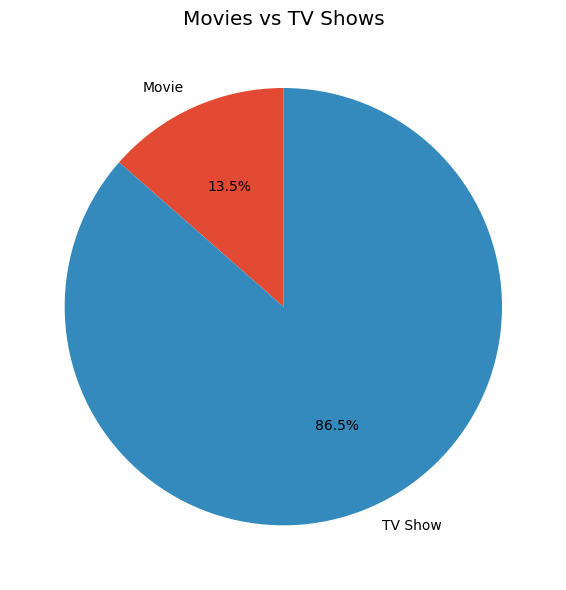


===== Insight: Movies vs TV Shows =====
Total Watch Hours : 3333467.73

Most Watched Content Type : TV Show
Watch Hours : 2882608.92

Content Type Distribution:
- Movie: 450858.81 hours (13.53%)
- TV Show: 2882608.92 hours (86.47%)

Insight:
- TV Shows account for the highest share of watch hours, indicating viewers spend more time watching episodic content.
- The distribution of watch hours across content types helps evaluate viewer preferences and optimize content investments.
- Understanding whether users prefer movies or TV shows supports content acquisition, recommendation strategies, and production planning.
- Monitoring content-type engagement enables better business decisions that improve user satisfaction and subscriber retention.


In [12]:
content=(

    eda

    .groupby("type")["Watch Hours"]

    .sum()

)

plt.figure(figsize=(6,6))

plt.pie(

    content,

    labels=content.index,

    autopct="%1.1f%%",

    startangle=90

)

plt.title("Movies vs TV Shows")

save_chart("03_Content_Type_Share.png")

print("\n===== Insight: Movies vs TV Shows =====")

total_watch_hours = content.sum()

print(f"Total Watch Hours : {total_watch_hours:.2f}")

top_type = content.idxmax()
top_hours = content.max()

print(f"\nMost Watched Content Type : {top_type}")
print(f"Watch Hours : {top_hours:.2f}")

print("\nContent Type Distribution:")
for content_type, hours in content.items():
    percentage = (hours / total_watch_hours) * 100
    print(f"- {content_type}: {hours:.2f} hours ({percentage:.2f}%)")

movie_hours = content.get("Movie", 0)
tv_hours = content.get("TV Show", 0)

print("\nInsight:")

if movie_hours > tv_hours:
    print("- Movies account for the highest share of watch hours, indicating stronger audience preference for movie content.")
elif tv_hours > movie_hours:
    print("- TV Shows account for the highest share of watch hours, indicating viewers spend more time watching episodic content.")
else:
    print("- Movies and TV Shows contribute equally to total watch hours.")

print("- The distribution of watch hours across content types helps evaluate viewer preferences and optimize content investments.")
print("- Understanding whether users prefer movies or TV shows supports content acquisition, recommendation strategies, and production planning.")
print("- Monitoring content-type engagement enables better business decisions that improve user satisfaction and subscriber retention.")

2026-07-21 21:46:38,650 | INFO | 04_Genre_Watch_Hours.png saved successfully.


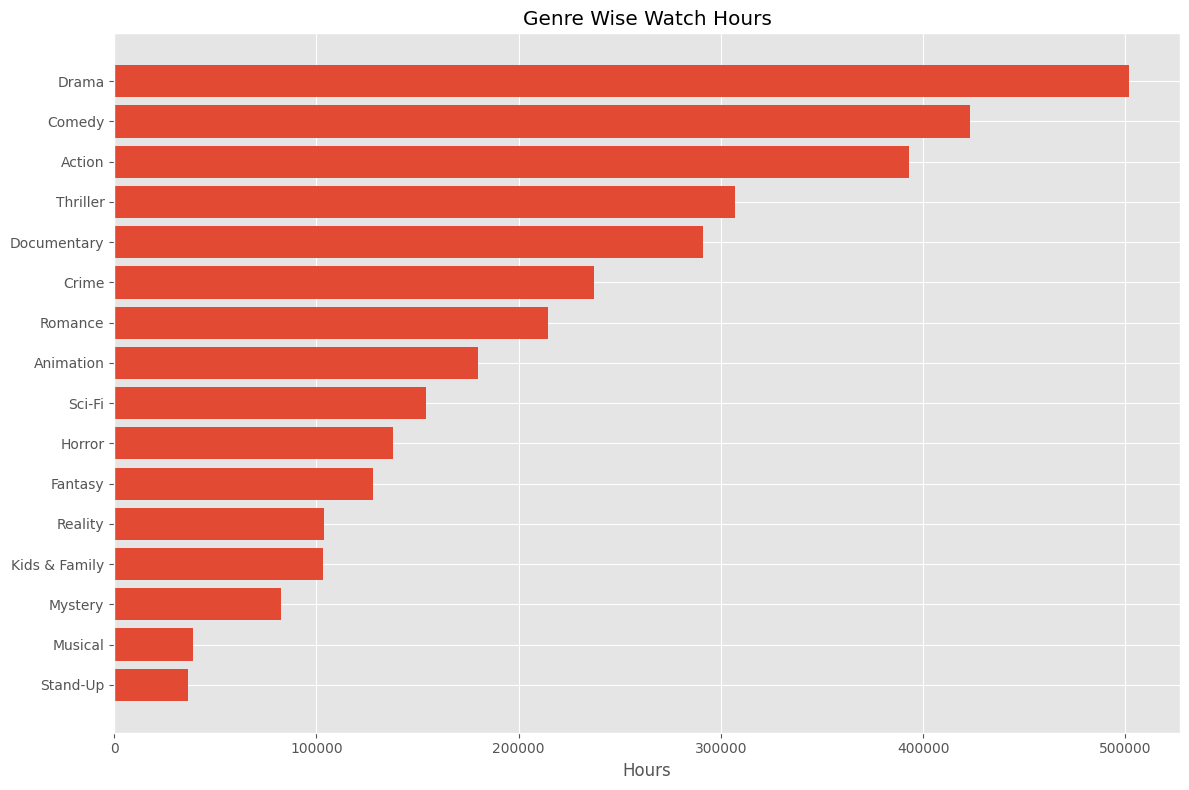


===== Insight: Genre-wise Watch Hours =====
Total Genres Analyzed : 16
Total Watch Hours : 3333467.73

Most Watched Genre : Drama
Watch Hours : 501884.47

Least Watched Genre : Stand-Up
Watch Hours : 36305.25

Genre-wise Watch Hours:
1. Drama: 501884.47 hours (15.06%)
2. Comedy: 423149.05 hours (12.69%)
3. Action: 393171.92 hours (11.79%)
4. Thriller: 307024.66 hours (9.21%)
5. Documentary: 291216.90 hours (8.74%)
6. Crime: 237435.84 hours (7.12%)
7. Romance: 214332.30 hours (6.43%)
8. Animation: 180093.94 hours (5.40%)
9. Sci-Fi: 154332.21 hours (4.63%)
10. Horror: 138033.61 hours (4.14%)
11. Fantasy: 127838.85 hours (3.84%)
12. Reality: 103954.91 hours (3.12%)
13. Kids & Family: 103118.07 hours (3.09%)
14. Mystery: 82552.37 hours (2.48%)
15. Musical: 39023.39 hours (1.17%)
16. Stand-Up: 36305.25 hours (1.09%)

Average Watch Hours per Genre : 208341.73

Top 5 Genres:
1. Drama: 501884.47 hours
2. Comedy: 423149.05 hours
3. Action: 393171.92 hours
4. Thriller: 307024.66 hours
5. Docume

In [13]:
genre=(

    eda

    .groupby("primary_genre")["Watch Hours"]

    .sum()

    .sort_values()

)

plt.figure(figsize=(12,8))

plt.barh(

    genre.index,

    genre.values

)

plt.title("Genre Wise Watch Hours")

plt.xlabel("Hours")

save_chart("04_Genre_Watch_Hours.png")

print("\n===== Insight: Genre-wise Watch Hours =====")

total_watch_hours = genre.sum()

print(f"Total Genres Analyzed : {len(genre)}")
print(f"Total Watch Hours : {total_watch_hours:.2f}")

top_genre = genre.idxmax()
top_hours = genre.max()

lowest_genre = genre.idxmin()
lowest_hours = genre.min()

print(f"\nMost Watched Genre : {top_genre}")
print(f"Watch Hours : {top_hours:.2f}")

print(f"\nLeast Watched Genre : {lowest_genre}")
print(f"Watch Hours : {lowest_hours:.2f}")

print("\nGenre-wise Watch Hours:")
for i, (g, hours) in enumerate(genre.sort_values(ascending=False).items(), start=1):
    percentage = (hours / total_watch_hours) * 100
    print(f"{i}. {g}: {hours:.2f} hours ({percentage:.2f}%)")

average_hours = genre.mean()

print(f"\nAverage Watch Hours per Genre : {average_hours:.2f}")

print("\nTop 5 Genres:")
for i, (g, hours) in enumerate(genre.sort_values(ascending=False).head(5).items(), start=1):
    print(f"{i}. {g}: {hours:.2f} hours")

print("\nInsight:")
print(f"- {top_genre} is the most watched genre with {top_hours:.2f} watch hours, indicating the highest audience engagement.")
print(f"- {lowest_genre} records the lowest watch hours ({lowest_hours:.2f}), suggesting comparatively lower viewer interest.")
print("- The top-performing genres contribute a significant share of total watch time and should be prioritized for future content acquisition and original productions.")
print("- Lower-performing genres should be evaluated to understand whether factors such as content quality, availability, or audience preferences are affecting engagement.")
print("- Genre-wise watch hour analysis supports recommendation systems, content strategy, marketing campaigns, and investment decisions.")

2026-07-21 21:46:39,328 | INFO | 05_Top_Countries.png saved successfully.


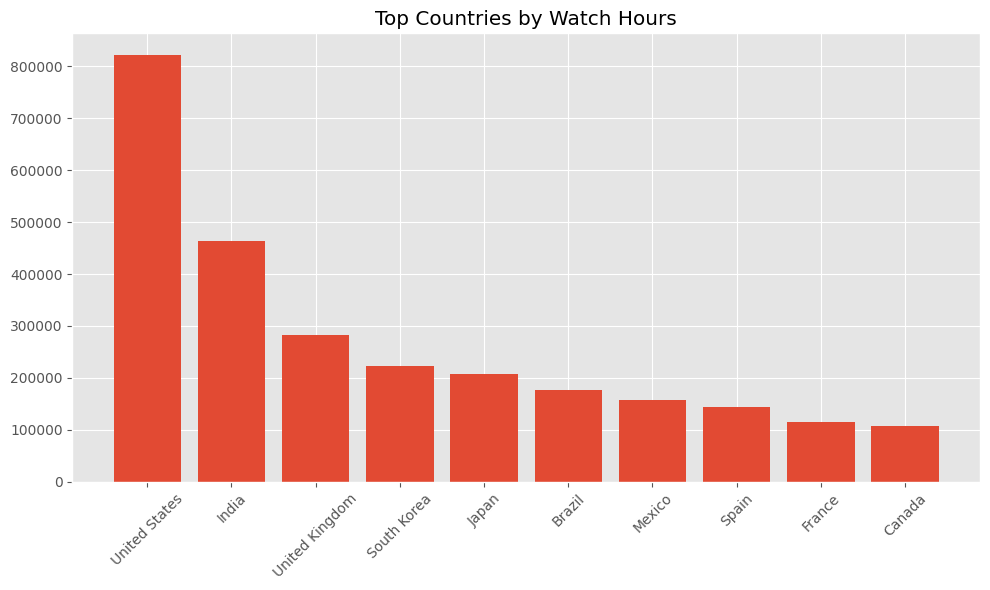


===== Insight: Top Countries by Watch Hours =====
Top Countries Analyzed : 10
Total Watch Hours (Top 10 Countries) : 2699847.67

Highest Watch Hours : United States (822684.68 hours)
Lowest Watch Hours (Top 10) : Canada (107072.95 hours)

Top 10 Countries by Watch Hours:
1. United States: 822684.68 hours (30.47%)
2. India: 464337.76 hours (17.20%)
3. United Kingdom: 282946.39 hours (10.48%)
4. South Korea: 223476.40 hours (8.28%)
5. Japan: 207130.86 hours (7.67%)
6. Brazil: 176353.60 hours (6.53%)
7. Mexico: 157176.86 hours (5.82%)
8. Spain: 143656.40 hours (5.32%)
9. France: 115011.76 hours (4.26%)
10. Canada: 107072.95 hours (3.97%)

Average Watch Hours : 269984.77

Insight:
- United States records the highest watch time with 822684.68 hours, indicating the strongest audience engagement.
- Canada contributes the lowest watch hours among the top 10 countries, with 107072.95 hours.
- The top-performing countries represent the platform's key markets and should be prioritized for region

In [14]:
country=(

    eda

    .groupby("country_y")["Watch Hours"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(10,6))

plt.bar(

    country.index,

    country.values

)

plt.xticks(rotation=45)

plt.title("Top Countries by Watch Hours")

save_chart("05_Top_Countries.png")

print("\n===== Insight: Top Countries by Watch Hours =====")

total_watch_hours = country.sum()

print(f"Top Countries Analyzed : {len(country)}")
print(f"Total Watch Hours (Top 10 Countries) : {total_watch_hours:.2f}")

top_country = country.idxmax()
top_hours = country.max()

lowest_country = country.idxmin()
lowest_hours = country.min()

print(f"\nHighest Watch Hours : {top_country} ({top_hours:.2f} hours)")
print(f"Lowest Watch Hours (Top 10) : {lowest_country} ({lowest_hours:.2f} hours)")

print("\nTop 10 Countries by Watch Hours:")
for i, (c, hours) in enumerate(country.items(), start=1):
    percentage = (hours / total_watch_hours) * 100
    print(f"{i}. {c}: {hours:.2f} hours ({percentage:.2f}%)")

average_hours = country.mean()
print(f"\nAverage Watch Hours : {average_hours:.2f}")

print("\nInsight:")
print(f"- {top_country} records the highest watch time with {top_hours:.2f} hours, indicating the strongest audience engagement.")
print(f"- {lowest_country} contributes the lowest watch hours among the top 10 countries, with {lowest_hours:.2f} hours.")
print("- The top-performing countries represent the platform's key markets and should be prioritized for regional content, marketing campaigns, and subscriber growth initiatives.")
print("- Geographic watch-hour analysis helps identify regional viewing trends, optimize localization strategies, and improve content recommendations.")
print("- Understanding country-wise engagement supports data-driven decisions for global expansion and content investment.")

2026-07-21 21:46:40,041 | INFO | 06_Top10_Titles.png saved successfully.


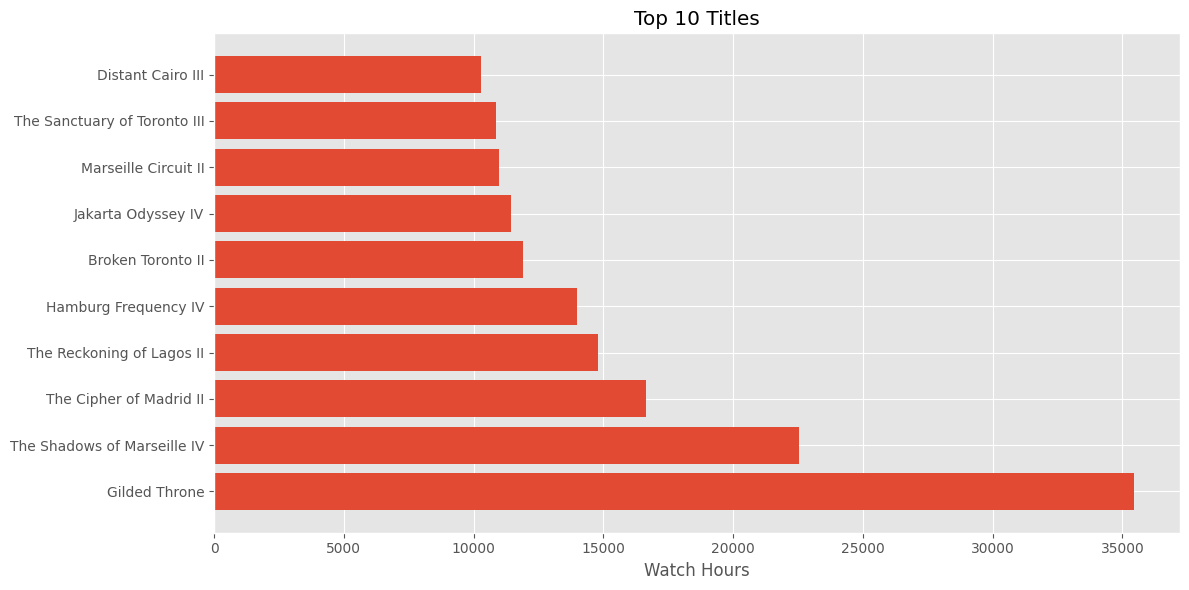


===== Insight: Top 10 Titles by Watch Hours =====
Top Titles Analyzed : 10
Total Watch Hours (Top 10) : 158805.70

Most Watched Title : Gilded Throne
Watch Hours : 35443.44

10th Ranked Title : Distant Cairo III
Watch Hours : 10266.91

Top 10 Titles by Watch Hours:
1. Gilded Throne: 35443.44 hours (22.32%)
2. The Shadows of Marseille IV: 22538.22 hours (14.19%)
3. The Cipher of Madrid II: 16659.99 hours (10.49%)
4. The Reckoning of Lagos II: 14778.55 hours (9.31%)
5. Hamburg Frequency IV: 13963.48 hours (8.79%)
6. Broken Toronto II: 11902.91 hours (7.50%)
7. Jakarta Odyssey IV: 11440.02 hours (7.20%)
8. Marseille Circuit II: 10967.34 hours (6.91%)
9. The Sanctuary of Toronto III: 10844.84 hours (6.83%)
10. Distant Cairo III: 10266.91 hours (6.47%)

Average Watch Hours (Top 10 Titles): 15880.57

Insight:
- 'Gilded Throne' is the most-watched title with 35443.44 watch hours, making it the platform's best-performing content.
- The top 10 titles contribute a significant share of total vie

In [15]:
titles_chart=(

    eda

    .groupby("title_name")["Watch Hours"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(12,6))

plt.barh(

    titles_chart.index,

    titles_chart.values

)

plt.title("Top 10 Titles")

plt.xlabel("Watch Hours")

save_chart("06_Top10_Titles.png")

print("\n===== Insight: Top 10 Titles by Watch Hours =====")

total_watch_hours = titles_chart.sum()

print(f"Top Titles Analyzed : {len(titles_chart)}")
print(f"Total Watch Hours (Top 10) : {total_watch_hours:.2f}")

top_title = titles_chart.idxmax()
top_hours = titles_chart.max()

lowest_title = titles_chart.idxmin()
lowest_hours = titles_chart.min()

print(f"\nMost Watched Title : {top_title}")
print(f"Watch Hours : {top_hours:.2f}")

print(f"\n10th Ranked Title : {lowest_title}")
print(f"Watch Hours : {lowest_hours:.2f}")

print("\nTop 10 Titles by Watch Hours:")
for i, (title, hours) in enumerate(titles_chart.items(), start=1):
    percentage = (hours / total_watch_hours) * 100
    print(f"{i}. {title}: {hours:.2f} hours ({percentage:.2f}%)")

average_hours = titles_chart.mean()
print(f"\nAverage Watch Hours (Top 10 Titles): {average_hours:.2f}")

print("\nInsight:")
print(f"- '{top_title}' is the most-watched title with {top_hours:.2f} watch hours, making it the platform's best-performing content.")
print("- The top 10 titles contribute a significant share of total viewing time, indicating that a small number of popular titles drive a large portion of audience engagement.")
print("- These high-performing titles can be used to guide future content acquisition, recommendation strategies, and promotional campaigns.")
print("- Analyzing the characteristics of top-performing titles helps identify viewer preferences and supports data-driven content investment decisions.")
print("- Monitoring title-level watch hours enables the platform to optimize its content catalog and maximize subscriber satisfaction.")

2026-07-21 21:46:40,452 | INFO | 07_Original_vs_Licensed.png saved successfully.


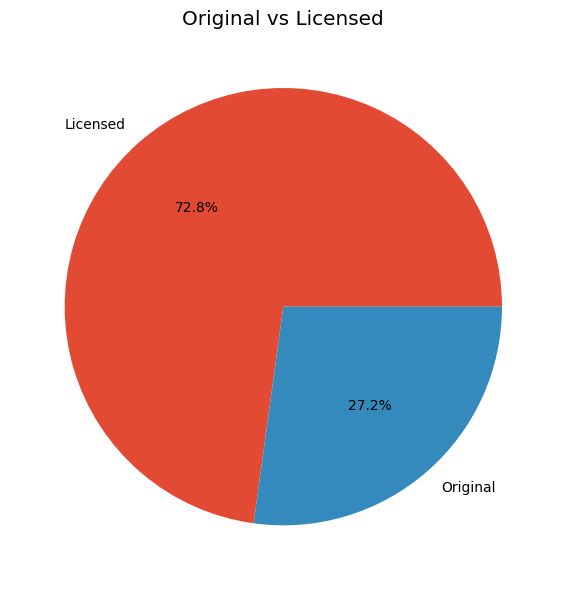


===== Insight: Original vs Licensed Content =====
Total Watch Hours : 3333467.73
Original Content : 905661.77 hours (27.17%)
Licensed Content : 2427805.97 hours (72.83%)

Content Performance:
Licensed content receives more watch hours than original content.
Difference in Watch Hours : 1522144.20

Insight:
- Licensed content generates the majority of watch time, showing its importance in maintaining audience engagement.
- A balanced library of original and licensed content helps attract new subscribers while retaining existing users.
- Comparing watch hours across content types supports strategic decisions on content acquisition, licensing budgets, and original content investments.
- This analysis enables the platform to optimize its content portfolio for maximum viewer engagement and long-term growth.


In [16]:
originals=(

    eda

    .groupby("is_original")["Watch Hours"]

    .sum()

)

plt.figure(figsize=(6,6))

plt.pie(

    originals,

    labels=["Licensed","Original"],

    autopct="%1.1f%%"

)

plt.title("Original vs Licensed")

save_chart("07_Original_vs_Licensed.png")

print("\n===== Insight: Original vs Licensed Content =====")

licensed_hours = originals.get(False, 0)
original_hours = originals.get(True, 0)

total_hours = licensed_hours + original_hours

licensed_pct = (licensed_hours / total_hours) * 100 if total_hours else 0
original_pct = (original_hours / total_hours) * 100 if total_hours else 0

print(f"Total Watch Hours : {total_hours:.2f}")
print(f"Original Content : {original_hours:.2f} hours ({original_pct:.2f}%)")
print(f"Licensed Content : {licensed_hours:.2f} hours ({licensed_pct:.2f}%)")

print("\nContent Performance:")
if original_hours > licensed_hours:
    print("Original content receives more watch hours than licensed content.")
else:
    print("Licensed content receives more watch hours than original content.")

difference = abs(original_hours - licensed_hours)
print(f"Difference in Watch Hours : {difference:.2f}")

print("\nInsight:")
if original_hours > licensed_hours:
    print("- Original content attracts the majority of viewer watch time, highlighting the value of investing in exclusive productions.")
else:
    print("- Licensed content generates the majority of watch time, showing its importance in maintaining audience engagement.")

print("- A balanced library of original and licensed content helps attract new subscribers while retaining existing users.")
print("- Comparing watch hours across content types supports strategic decisions on content acquisition, licensing budgets, and original content investments.")
print("- This analysis enables the platform to optimize its content portfolio for maximum viewer engagement and long-term growth.")

2026-07-21 21:46:41,008 | INFO | 08_Languages.png saved successfully.


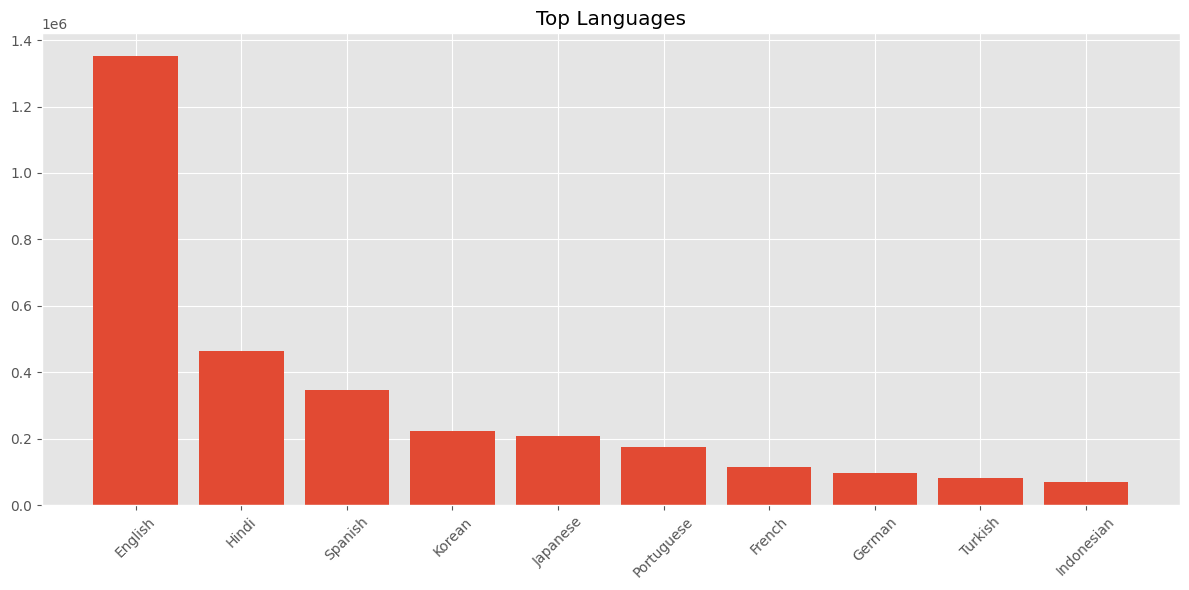


===== Insight: Top Languages by Watch Hours =====
Top Languages Analyzed : 10
Total Watch Hours (Top 10 Languages) : 3137568.66

Most Watched Language : English (1352815.82 hours)
Least Watched (Top 10) : Indonesian (71049.87 hours)

Top 10 Languages by Watch Hours:
1. English: 1352815.82 hours (43.12%)
2. Hindi: 464337.76 hours (14.80%)
3. Spanish: 347738.22 hours (11.08%)
4. Korean: 223476.40 hours (7.12%)
5. Japanese: 207130.86 hours (6.60%)
6. Portuguese: 176353.60 hours (5.62%)
7. French: 115011.76 hours (3.67%)
8. German: 96934.35 hours (3.09%)
9. Turkish: 82720.01 hours (2.64%)
10. Indonesian: 71049.87 hours (2.26%)

Insight:
- English is the most watched language with 1352815.82 total watch hours, indicating the highest viewer engagement.
- Indonesian has the lowest watch hours among the top 10 languages, with 71049.87 hours.
- Languages with higher watch hours represent the platform's strongest-performing content categories and should be prioritized for future acquisitions an

In [17]:
language=(

    eda

    .groupby("language")["Watch Hours"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(12,6))

plt.bar(

    language.index,

    language.values

)

plt.xticks(rotation=45)

plt.title("Top Languages")

save_chart("08_Languages.png")

print("\n===== Insight: Top Languages by Watch Hours =====")

total_watch_hours = language.sum()

print(f"Top Languages Analyzed : {len(language)}")
print(f"Total Watch Hours (Top 10 Languages) : {total_watch_hours:.2f}")

top_language = language.idxmax()
top_hours = language.max()

lowest_language = language.idxmin()
lowest_hours = language.min()

print(f"\nMost Watched Language : {top_language} ({top_hours:.2f} hours)")
print(f"Least Watched (Top 10) : {lowest_language} ({lowest_hours:.2f} hours)")

print("\nTop 10 Languages by Watch Hours:")
for i, (lang, hours) in enumerate(language.items(), start=1):
    percentage = (hours / total_watch_hours) * 100
    print(f"{i}. {lang}: {hours:.2f} hours ({percentage:.2f}%)")

print("\nInsight:")
print(f"- {top_language} is the most watched language with {top_hours:.2f} total watch hours, indicating the highest viewer engagement.")
print(f"- {lowest_language} has the lowest watch hours among the top 10 languages, with {lowest_hours:.2f} hours.")
print("- Languages with higher watch hours represent the platform's strongest-performing content categories and should be prioritized for future acquisitions and original productions.")
print("- Expanding content in high-performing languages while promoting underperforming languages can help increase audience reach and engagement.")
print("- Language-wise watch hour analysis supports localization strategies, regional content planning, and data-driven business decisions.")

2026-07-21 21:46:41,651 | INFO | 09_Release_Year.png saved successfully.


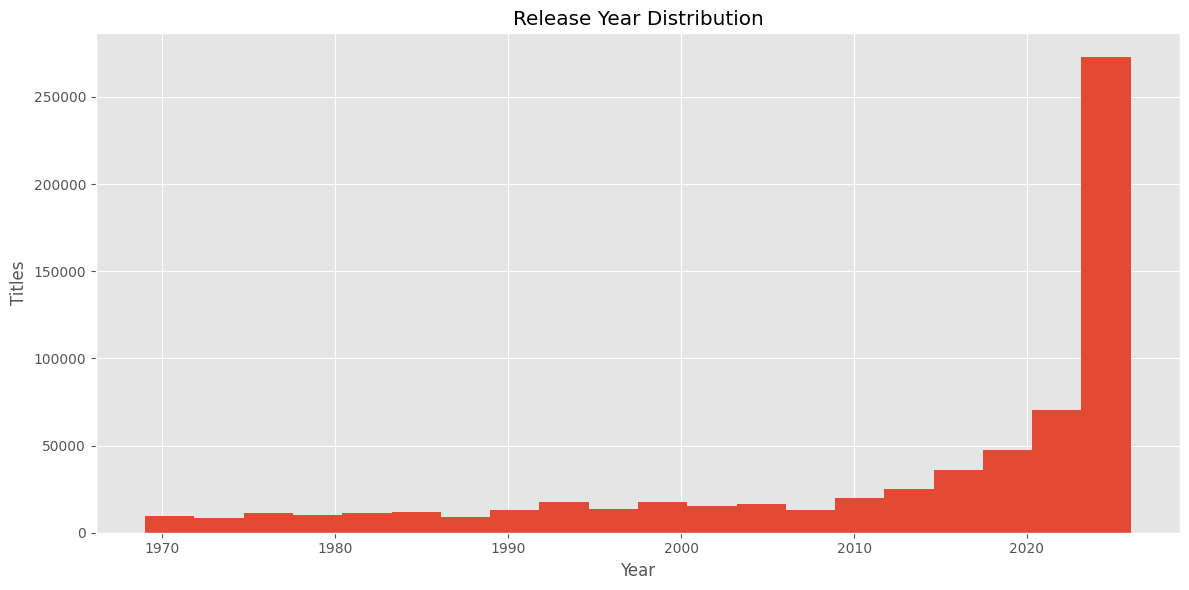


===== Insight: Release Year Distribution =====
Total Titles : 650000
Earliest Release Year : 1969
Latest Release Year : 2026
Average Release Year : 2014
Median Release Year : 2021

Release Year Categories:
Before 2000 : 127166
2000 - 2014 : 96142
2015 and Later : 426692

Most Common Release Year : 2026
Titles Released : 186774

Insight:
- The content library spans from 1969 to 2026, providing a diverse catalog across multiple decades.
- The average release year is 2014, indicating that the platform primarily features modern content.
- The year 2026 contains the highest number of released titles (186774).
- A higher concentration of recent releases suggests that the platform regularly updates its content library to meet viewer demand.
- Maintaining a balanced mix of classic and newly released titles helps attract different audience segments and improves subscriber retention.


In [18]:
plt.figure(figsize=(12,6))

plt.hist(

    eda["release_year"],

    bins=20

)

plt.title("Release Year Distribution")

plt.xlabel("Year")

plt.ylabel("Titles")

save_chart("09_Release_Year.png")

print("\n===== Insight: Release Year Distribution =====")

release = eda["release_year"].dropna()

print(f"Total Titles : {len(release)}")
print(f"Earliest Release Year : {int(release.min())}")
print(f"Latest Release Year : {int(release.max())}")
print(f"Average Release Year : {release.mean():.0f}")
print(f"Median Release Year : {release.median():.0f}")

old_titles = (release < 2000).sum()
mid_titles = ((release >= 2000) & (release < 2015)).sum()
recent_titles = (release >= 2015).sum()

print("\nRelease Year Categories:")
print(f"Before 2000 : {old_titles}")
print(f"2000 - 2014 : {mid_titles}")
print(f"2015 and Later : {recent_titles}")

most_common_year = release.mode().iloc[0]
most_common_count = (release == most_common_year).sum()

print(f"\nMost Common Release Year : {int(most_common_year)}")
print(f"Titles Released : {most_common_count}")

print("\nInsight:")
print(f"- The content library spans from {int(release.min())} to {int(release.max())}, providing a diverse catalog across multiple decades.")
print(f"- The average release year is {release.mean():.0f}, indicating that the platform primarily features modern content.")
print(f"- The year {int(most_common_year)} contains the highest number of released titles ({most_common_count}).")
print("- A higher concentration of recent releases suggests that the platform regularly updates its content library to meet viewer demand.")
print("- Maintaining a balanced mix of classic and newly released titles helps attract different audience segments and improves subscriber retention.")

2026-07-21 21:46:42,213 | INFO | 10_Quality_Score.png saved successfully.


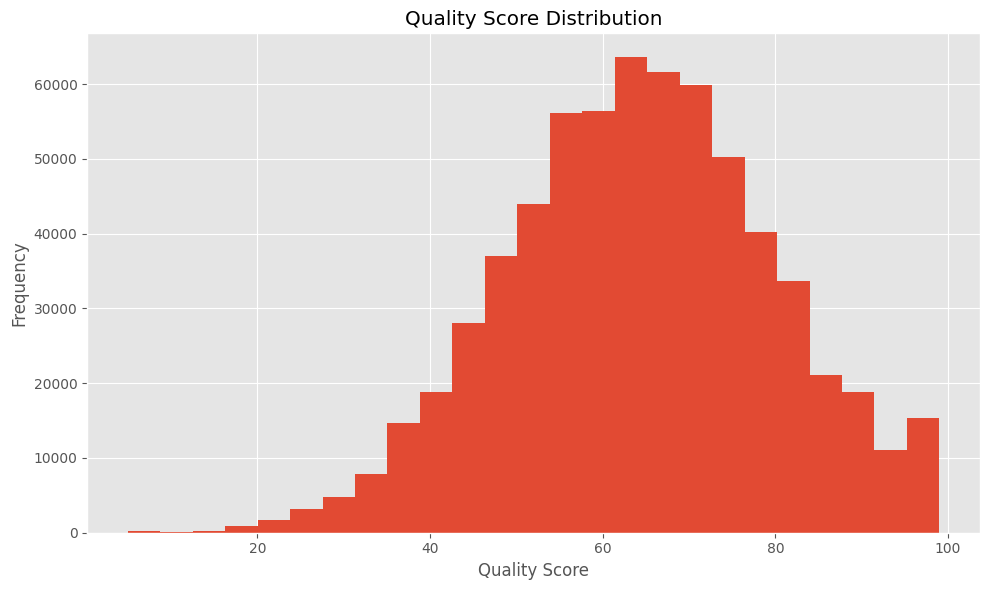


===== Insight: Quality Score Distribution =====
Total Records : 650000
Average Quality Score : 64.28
Median Quality Score : 64.40
Highest Quality Score : 99.00
Lowest Quality Score : 5.00
Standard Deviation : 15.40

Quality Score Categories:
High Quality (>=80) : 102918
Medium Quality (60-79) : 294409
Low Quality (<60) : 252673

Insight:
- The average quality score is 64.28, indicating the overall content quality across the platform.
- The median quality score of 64.40 suggests that half of the content has a quality score above this value.
- Content with quality scores of 80 or above represents high-quality titles that are more likely to deliver a better viewing experience.
- Lower quality scores may indicate content that requires quality improvements, remastering, or replacement.
- Analyzing quality score distribution helps prioritize content investments, improve user satisfaction, and support data-driven content strategy.


In [19]:
plt.figure(figsize=(10,6))

plt.hist(

    eda["quality_score"],

    bins=25

)

plt.title("Quality Score Distribution")

plt.xlabel("Quality Score")

plt.ylabel("Frequency")

save_chart("10_Quality_Score.png")

print("\n===== Insight: Quality Score Distribution =====")

quality = eda["quality_score"].dropna()

mean_quality = quality.mean()
median_quality = quality.median()
min_quality = quality.min()
max_quality = quality.max()
std_quality = quality.std()

print(f"Total Records : {len(quality)}")
print(f"Average Quality Score : {mean_quality:.2f}")
print(f"Median Quality Score : {median_quality:.2f}")
print(f"Highest Quality Score : {max_quality:.2f}")
print(f"Lowest Quality Score : {min_quality:.2f}")
print(f"Standard Deviation : {std_quality:.2f}")

high_quality = (quality >= 80).sum()
medium_quality = ((quality >= 60) & (quality < 80)).sum()
low_quality = (quality < 60).sum()

print("\nQuality Score Categories:")
print(f"High Quality (>=80) : {high_quality}")
print(f"Medium Quality (60-79) : {medium_quality}")
print(f"Low Quality (<60) : {low_quality}")

print("\nInsight:")
print(f"- The average quality score is {mean_quality:.2f}, indicating the overall content quality across the platform.")
print(f"- The median quality score of {median_quality:.2f} suggests that half of the content has a quality score above this value.")
print("- Content with quality scores of 80 or above represents high-quality titles that are more likely to deliver a better viewing experience.")
print("- Lower quality scores may indicate content that requires quality improvements, remastering, or replacement.")
print("- Analyzing quality score distribution helps prioritize content investments, improve user satisfaction, and support data-driven content strategy.")

In [20]:
summary=(

    eda

    .groupby("primary_genre")

    .agg(

        Total_Hours=("Watch Hours","sum"),

        Total_Plays=("watch_id","count"),

        Avg_Completion=("completion_pct","mean")

    )

    .reset_index()

)

summary.to_csv(

    "charts/Genre_Summary.csv",

    index=False

)

logger.info("Genre summary exported.")

2026-07-21 21:46:42,610 | INFO | Genre summary exported.


2026-07-21 21:46:42,833 | INFO | 11_Subscriber_Plans.png saved successfully.


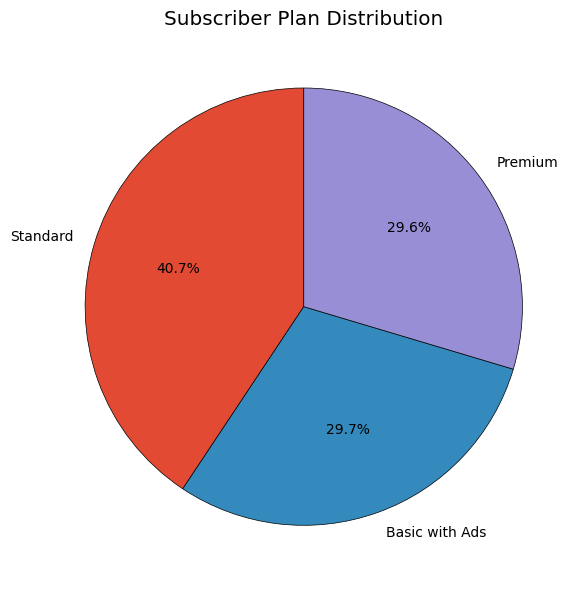

2026-07-21 21:46:42,883 | INFO | Subscriber Plan chart generated.



===== Insight: Subscriber Plan Distribution =====
Total Subscribers : 15000

Most Popular Plan : Standard (6100 subscribers)
Least Popular Plan : Premium (4442 subscribers)

Subscription Plan Distribution:
- Standard: 6100 subscribers (40.67%)
- Basic with Ads: 4458 subscribers (29.72%)
- Premium: 4442 subscribers (29.61%)

Insight:
- The Standard plan is the most popular subscription, accounting for 40.67% of all subscribers.
- The Premium plan has the fewest subscribers, indicating comparatively lower customer preference.
- The subscription mix provides valuable insights into customer purchasing behavior and plan preferences.
- Understanding plan distribution helps optimize pricing strategies, promotional offers, and subscription upgrades.
- Monitoring subscription trends enables the business to improve customer retention and maximize recurring revenue.


In [21]:
# ---------------------------------------------------
# SUBSCRIPTION PLAN DISTRIBUTION
# ---------------------------------------------------

plan = (

    subscribers

    .groupby("plan_type")

    .size()

    .sort_values(ascending=False)

)

plt.figure(figsize=(7,6))

plt.pie(

    plan.values,

    labels=plan.index,

    autopct="%1.1f%%",

    startangle=90,

    wedgeprops={"edgecolor":"black"}

)

plt.title("Subscriber Plan Distribution")

save_chart("11_Subscriber_Plans.png")

print("\n===== Insight: Subscriber Plan Distribution =====")

total_subscribers = plan.sum()

print(f"Total Subscribers : {total_subscribers}")

top_plan = plan.idxmax()
top_count = plan.max()

lowest_plan = plan.idxmin()
lowest_count = plan.min()

print(f"\nMost Popular Plan : {top_plan} ({top_count} subscribers)")
print(f"Least Popular Plan : {lowest_plan} ({lowest_count} subscribers)")

print("\nSubscription Plan Distribution:")
for plan_name, count in plan.items():
    percentage = (count / total_subscribers) * 100
    print(f"- {plan_name}: {count} subscribers ({percentage:.2f}%)")

print("\nInsight:")
print(f"- The {top_plan} plan is the most popular subscription, accounting for {(top_count/total_subscribers)*100:.2f}% of all subscribers.")
print(f"- The {lowest_plan} plan has the fewest subscribers, indicating comparatively lower customer preference.")
print("- The subscription mix provides valuable insights into customer purchasing behavior and plan preferences.")
print("- Understanding plan distribution helps optimize pricing strategies, promotional offers, and subscription upgrades.")
print("- Monitoring subscription trends enables the business to improve customer retention and maximize recurring revenue.")

logger.info("Subscriber Plan chart generated.")

2026-07-21 21:46:43,213 | INFO | 12_Device_Usage.png saved successfully.


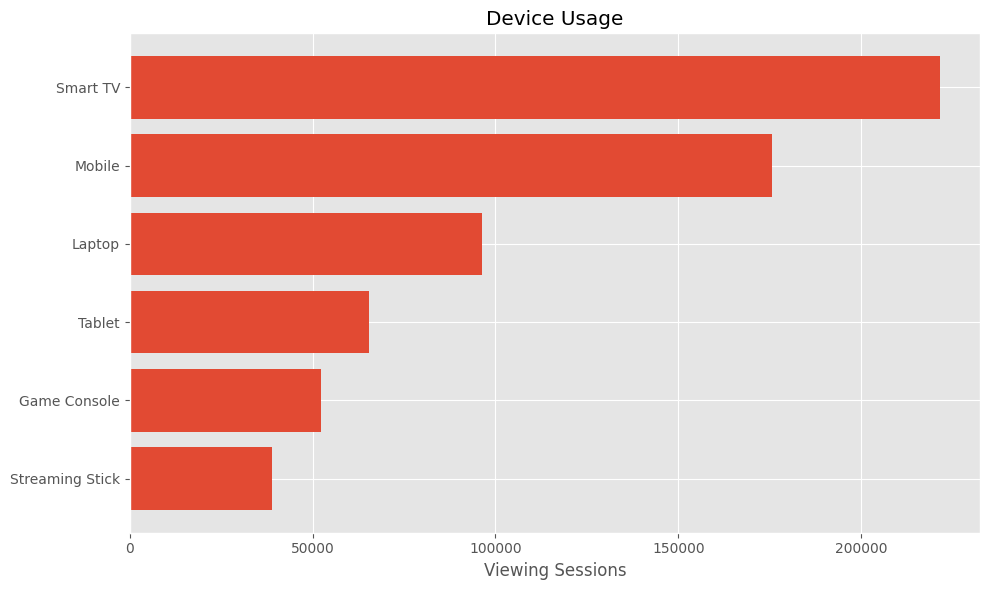


===== Insight: Device Usage =====
Total Viewing Sessions : 650000

Most Used Device : Smart TV (221446 sessions)
Least Used Device : Streaming Stick (38943 sessions)

Viewing Sessions by Device:
- Smart TV: 221446 sessions (34.07%)
- Mobile: 175605 sessions (27.02%)
- Laptop: 96408 sessions (14.83%)
- Tablet: 65276 sessions (10.04%)
- Game Console: 52322 sessions (8.05%)
- Streaming Stick: 38943 sessions (5.99%)

Average Sessions per Device : 108333.33

Insight:
- Smart TV is the most frequently used device with 221446 viewing sessions, making it the preferred platform for content consumption.
- Streaming Stick records the fewest viewing sessions (38943), indicating lower user activity on this device.
- Device usage patterns help identify where users consume content most frequently and support platform optimization.
- Prioritizing performance improvements and feature enhancements for the most-used devices can improve user experience and engagement.
- These insights also help guide tes

In [22]:
device=(

    eda

    .groupby("device")

    .size()

    .sort_values()

)

plt.figure(figsize=(10,6))

plt.barh(

    device.index,

    device.values

)

plt.xlabel("Viewing Sessions")

plt.title("Device Usage")

save_chart("12_Device_Usage.png")

print("\n===== Insight: Device Usage =====")

total_sessions = device.sum()

print(f"Total Viewing Sessions : {total_sessions}")

top_device = device.idxmax()
top_sessions = device.max()

least_device = device.idxmin()
least_sessions = device.min()

print(f"\nMost Used Device : {top_device} ({top_sessions} sessions)")
print(f"Least Used Device : {least_device} ({least_sessions} sessions)")

print("\nViewing Sessions by Device:")
for dev, sessions in device.sort_values(ascending=False).items():
    percentage = (sessions / total_sessions) * 100
    print(f"- {dev}: {sessions} sessions ({percentage:.2f}%)")

average_sessions = device.mean()
print(f"\nAverage Sessions per Device : {average_sessions:.2f}")

print("\nInsight:")
print(f"- {top_device} is the most frequently used device with {top_sessions} viewing sessions, making it the preferred platform for content consumption.")
print(f"- {least_device} records the fewest viewing sessions ({least_sessions}), indicating lower user activity on this device.")
print("- Device usage patterns help identify where users consume content most frequently and support platform optimization.")
print("- Prioritizing performance improvements and feature enhancements for the most-used devices can improve user experience and engagement.")
print("- These insights also help guide testing, application compatibility, and future product development decisions.")

2026-07-21 21:46:43,593 | INFO | 13_Primary_Device.png saved successfully.


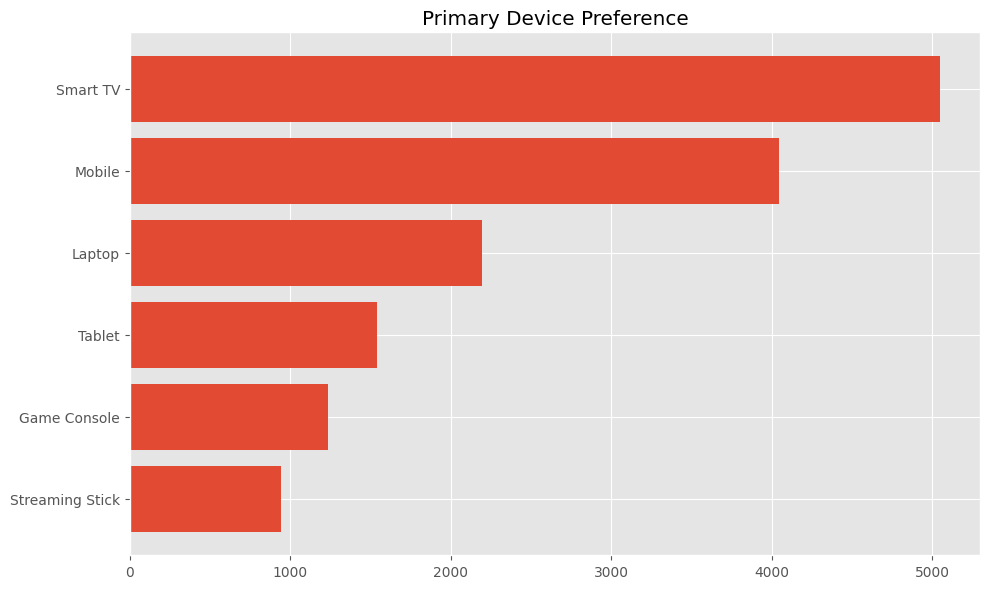


===== Insight: Primary Device Preference =====
Total Subscribers : 15000

Most Preferred Device : Smart TV (5045 subscribers)
Least Preferred Device : Streaming Stick (944 subscribers)

Device-wise Subscriber Distribution:
- Smart TV: 5045 subscribers (33.63%)
- Mobile: 4044 subscribers (26.96%)
- Laptop: 2197 subscribers (14.65%)
- Tablet: 1538 subscribers (10.25%)
- Game Console: 1232 subscribers (8.21%)
- Streaming Stick: 944 subscribers (6.29%)

Insight:
- Smart TV is the most preferred device with 5045 subscribers, indicating it is the primary platform used for streaming.
- Streaming Stick has the lowest number of users (944), suggesting comparatively lower adoption.
- Device preference analysis helps optimize the streaming application for the most commonly used platforms.
- Understanding user device preferences supports better UI/UX design, performance optimization, and targeted feature development.
- These insights also help prioritize testing and compatibility for devices with

In [23]:
primary=(

    subscribers

    .groupby("primary_device")

    .size()

    .sort_values()

)

plt.figure(figsize=(10,6))

plt.barh(

    primary.index,

    primary.values

)

plt.title("Primary Device Preference")

save_chart("13_Primary_Device.png")

print("\n===== Insight: Primary Device Preference =====")

total_users = primary.sum()

print(f"Total Subscribers : {total_users}")

top_device = primary.idxmax()
top_count = primary.max()

lowest_device = primary.idxmin()
lowest_count = primary.min()

print(f"\nMost Preferred Device : {top_device} ({top_count} subscribers)")
print(f"Least Preferred Device : {lowest_device} ({lowest_count} subscribers)")

print("\nDevice-wise Subscriber Distribution:")
for device, count in primary.sort_values(ascending=False).items():
    percentage = (count / total_users) * 100
    print(f"- {device}: {count} subscribers ({percentage:.2f}%)")

print("\nInsight:")
print(f"- {top_device} is the most preferred device with {top_count} subscribers, indicating it is the primary platform used for streaming.")
print(f"- {lowest_device} has the lowest number of users ({lowest_count}), suggesting comparatively lower adoption.")
print("- Device preference analysis helps optimize the streaming application for the most commonly used platforms.")
print("- Understanding user device preferences supports better UI/UX design, performance optimization, and targeted feature development.")
print("- These insights also help prioritize testing and compatibility for devices with the highest user base.")

2026-07-21 21:46:43,990 | INFO | 14_Age_Distribution.png saved successfully.


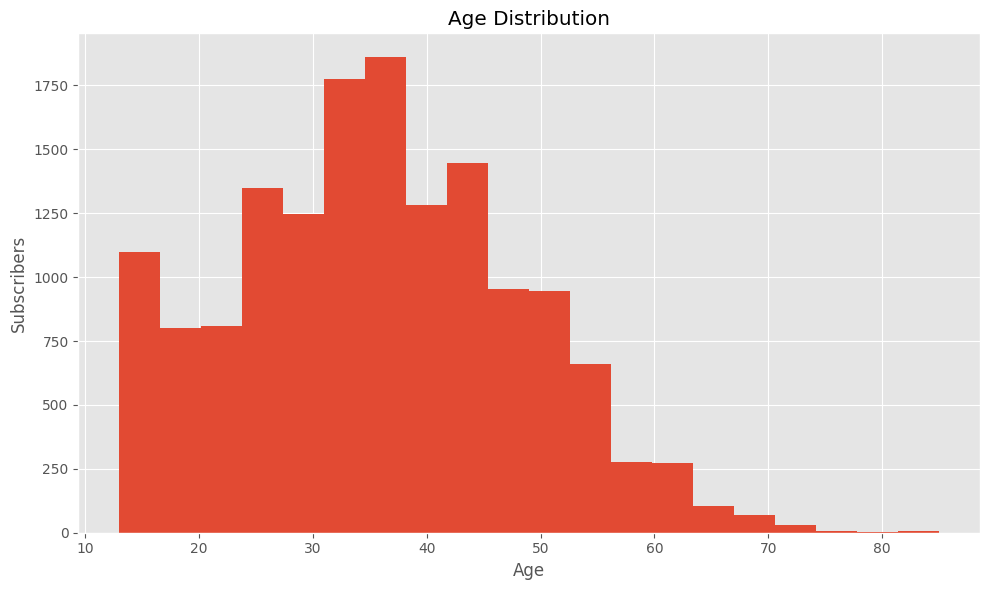


===== Insight: Age Distribution =====
Total Subscribers : 15000
Average Age : 35.62 years
Median Age : 35.00 years
Youngest Subscriber : 13 years
Oldest Subscriber : 85 years
Standard Deviation : 12.53 years

Age Group Distribution:
18-24 Years : 1715
25-34 Years : 4094
35-49 Years : 5835
50+ Years : 2086

Insight:
- The average subscriber age is 35.62 years, with a median age of 35.00 years.
- The histogram illustrates how subscribers are distributed across different age groups.
- The age group with the highest number of subscribers represents the platform's primary target audience.
- Understanding age demographics helps personalize content recommendations, improve marketing campaigns, and optimize content acquisition.
- Age distribution analysis supports strategic decisions related to customer segmentation and audience engagement.


In [24]:
plt.figure(figsize=(10,6))

plt.hist(

    subscribers["age"],

    bins=20

)

plt.xlabel("Age")

plt.ylabel("Subscribers")

plt.title("Age Distribution")

save_chart("14_Age_Distribution.png")

print("\n===== Insight: Age Distribution =====")

age = subscribers["age"].dropna()

mean_age = age.mean()
median_age = age.median()
min_age = age.min()
max_age = age.max()
std_age = age.std()

print(f"Total Subscribers : {len(age)}")
print(f"Average Age : {mean_age:.2f} years")
print(f"Median Age : {median_age:.2f} years")
print(f"Youngest Subscriber : {min_age} years")
print(f"Oldest Subscriber : {max_age} years")
print(f"Standard Deviation : {std_age:.2f} years")

young = ((age >= 18) & (age <= 24)).sum()
adult = ((age >= 25) & (age <= 34)).sum()
middle = ((age >= 35) & (age <= 49)).sum()
senior = (age >= 50).sum()

print("\nAge Group Distribution:")
print(f"18-24 Years : {young}")
print(f"25-34 Years : {adult}")
print(f"35-49 Years : {middle}")
print(f"50+ Years : {senior}")

print("\nInsight:")
print(f"- The average subscriber age is {mean_age:.2f} years, with a median age of {median_age:.2f} years.")
print("- The histogram illustrates how subscribers are distributed across different age groups.")
print("- The age group with the highest number of subscribers represents the platform's primary target audience.")
print("- Understanding age demographics helps personalize content recommendations, improve marketing campaigns, and optimize content acquisition.")
print("- Age distribution analysis supports strategic decisions related to customer segmentation and audience engagement.")

2026-07-21 21:46:44,313 | INFO | 15_Gender.png saved successfully.


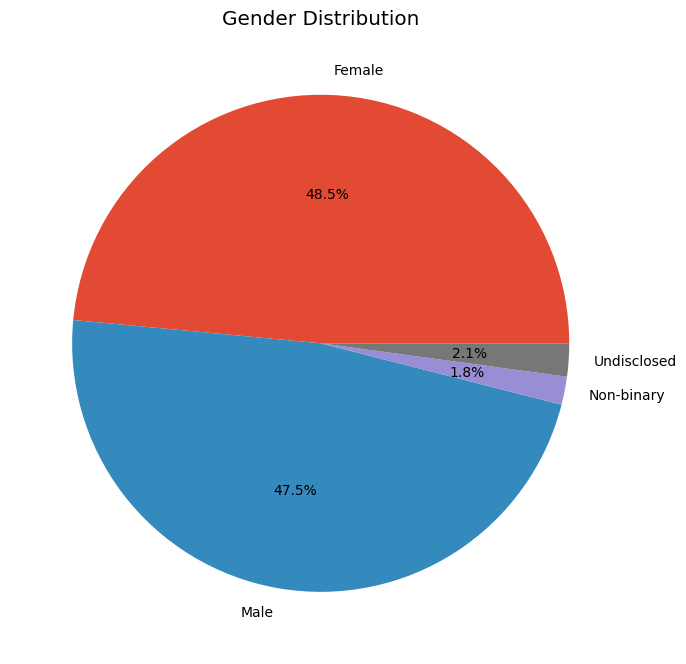


===== Insight: Gender Distribution =====
Total Subscribers : 15000

Gender Distribution:
- Female: 7276 subscribers (48.51%)
- Male: 7128 subscribers (47.52%)
- Non-binary: 274 subscribers (1.83%)
- Undisclosed: 322 subscribers (2.15%)

Largest Gender Group : Female
Subscribers : 7276 (48.51%)

Insight:
- Female represents the largest share of subscribers (48.51%), making it the dominant user segment.
- The gender distribution provides insights into the platform's audience demographics.
- A balanced gender distribution indicates broad audience appeal, while an uneven distribution may highlight opportunities for targeted marketing.
- Understanding gender demographics helps personalize recommendations, optimize content strategy, and improve customer engagement.


In [25]:
gender=(

    subscribers

    .groupby("gender")

    .size()

)

plt.figure(figsize=(7,7))

plt.pie(

    gender,

    labels=gender.index,

    autopct="%1.1f%%"

)

plt.title("Gender Distribution")

save_chart("15_Gender.png")

print("\n===== Insight: Gender Distribution =====")

total_subscribers = gender.sum()

print(f"Total Subscribers : {total_subscribers}")

print("\nGender Distribution:")
for gen, count in gender.items():
    percentage = (count / total_subscribers) * 100
    print(f"- {gen}: {count} subscribers ({percentage:.2f}%)")

dominant_gender = gender.idxmax()
dominant_count = gender.max()
dominant_percentage = (dominant_count / total_subscribers) * 100

print(f"\nLargest Gender Group : {dominant_gender}")
print(f"Subscribers : {dominant_count} ({dominant_percentage:.2f}%)")

print("\nInsight:")
print(f"- {dominant_gender} represents the largest share of subscribers ({dominant_percentage:.2f}%), making it the dominant user segment.")
print("- The gender distribution provides insights into the platform's audience demographics.")
print("- A balanced gender distribution indicates broad audience appeal, while an uneven distribution may highlight opportunities for targeted marketing.")
print("- Understanding gender demographics helps personalize recommendations, optimize content strategy, and improve customer engagement.")

2026-07-21 21:46:44,845 | INFO | 16_Genre_Completion.png saved successfully.


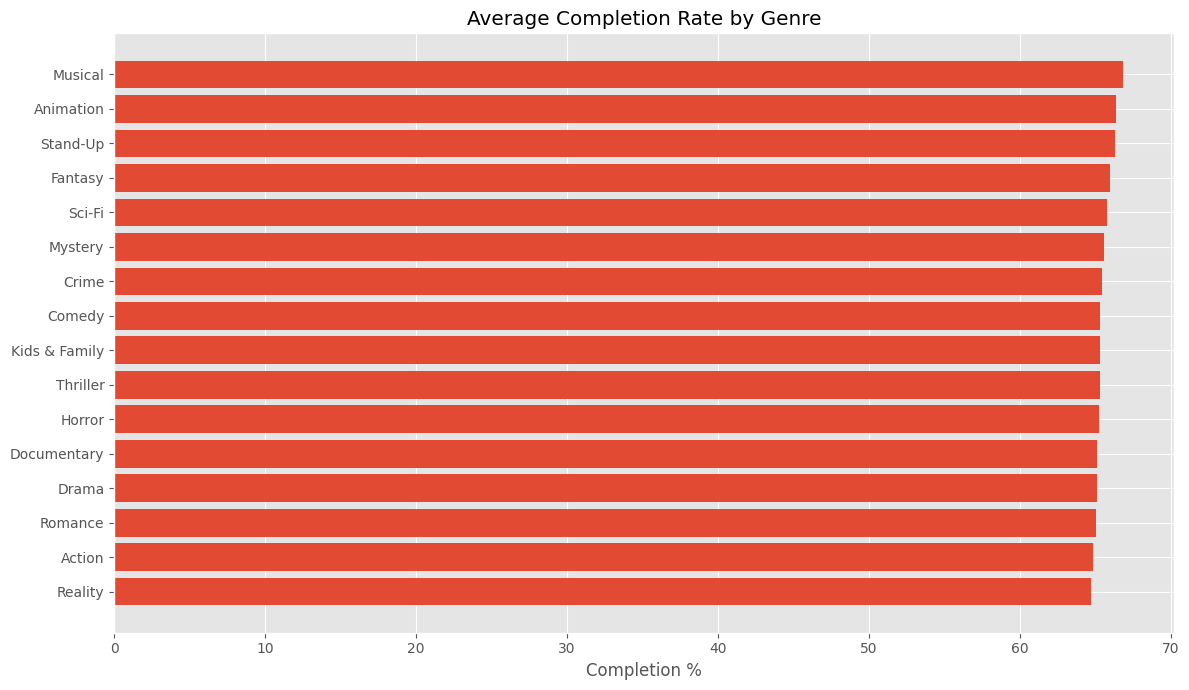


===== Insight: Average Completion Rate by Genre =====
Total Genres Analyzed : 16

Highest Completion Genre : Musical (66.83%)
Lowest Completion Genre  : Reality (64.70%)

Completion Rate by Genre:
- Reality: 64.70%
- Action: 64.81%
- Romance: 65.00%
- Drama: 65.10%
- Documentary: 65.13%
- Horror: 65.26%
- Thriller: 65.31%
- Kids & Family: 65.31%
- Comedy: 65.32%
- Crime: 65.46%
- Mystery: 65.56%
- Sci-Fi: 65.79%
- Fantasy: 65.97%
- Stand-Up: 66.32%
- Animation: 66.38%
- Musical: 66.83%

Overall Average Completion Rate : 65.52%

Top 5 Genres by Completion Rate:
1. Musical: 66.83%
2. Animation: 66.38%
3. Stand-Up: 66.32%
4. Fantasy: 65.97%
5. Sci-Fi: 65.79%

Insight:
- Musical has the highest average completion rate (66.83%), indicating that viewers are more likely to finish content in this genre.
- Reality has the lowest completion rate (64.70%), suggesting comparatively lower audience engagement.
- Genres with higher completion rates reflect stronger viewer interest and can be priorit

In [26]:
completion=(

    eda

    .groupby("primary_genre")

    ["completion_pct"]

    .mean()

    .sort_values()

)

plt.figure(figsize=(12,7))

plt.barh(

    completion.index,

    completion.values

)

plt.xlabel("Completion %")

plt.title("Average Completion Rate by Genre")

save_chart("16_Genre_Completion.png")

print("\n===== Insight: Average Completion Rate by Genre =====")

print(f"Total Genres Analyzed : {len(completion)}")

best_genre = completion.idxmax()
best_completion = completion.max()

lowest_genre = completion.idxmin()
lowest_completion = completion.min()

print(f"\nHighest Completion Genre : {best_genre} ({best_completion:.2f}%)")
print(f"Lowest Completion Genre  : {lowest_genre} ({lowest_completion:.2f}%)")

print("\nCompletion Rate by Genre:")
for genre, value in completion.items():
    print(f"- {genre}: {value:.2f}%")

overall_completion = completion.mean()
print(f"\nOverall Average Completion Rate : {overall_completion:.2f}%")

print("\nTop 5 Genres by Completion Rate:")
for i, (genre, value) in enumerate(completion.sort_values(ascending=False).head(5).items(), start=1):
    print(f"{i}. {genre}: {value:.2f}%")

print("\nInsight:")
print(f"- {best_genre} has the highest average completion rate ({best_completion:.2f}%), indicating that viewers are more likely to finish content in this genre.")
print(f"- {lowest_genre} has the lowest completion rate ({lowest_completion:.2f}%), suggesting comparatively lower audience engagement.")
print("- Genres with higher completion rates reflect stronger viewer interest and can be prioritized for future content investments.")
print("- Genres with lower completion rates should be analyzed to identify factors such as content length, quality, or audience preferences that may affect engagement.")
print("- Completion rate by genre is an important KPI for evaluating content performance and improving recommendation strategies.")

2026-07-21 21:46:45,272 | INFO | 17_WatchTime_by_Plan.png saved successfully.


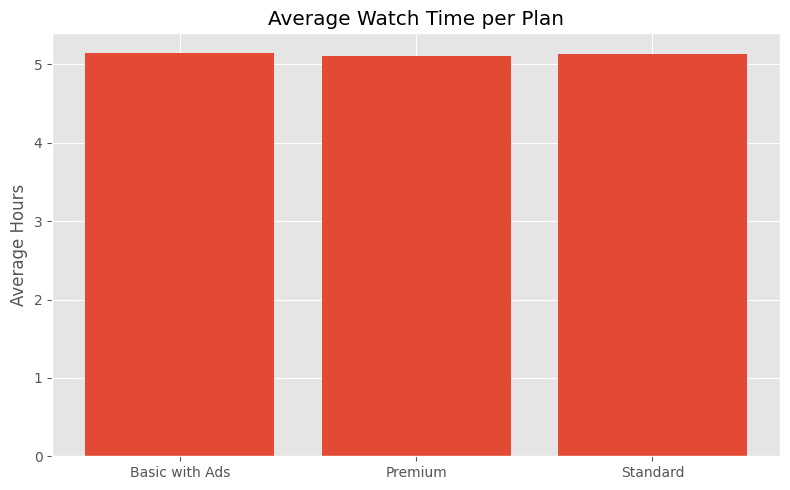


===== Insight: Average Watch Time by Plan =====
Total Subscription Plans : 3

Highest Average Watch Time : Basic with Ads (5.14 hours)
Lowest Average Watch Time  : Premium (5.11 hours)

Average Watch Hours by Plan:
- Basic with Ads: 5.14 hours
- Premium: 5.11 hours
- Standard: 5.13 hours

Overall Average Watch Time : 5.13 hours

Insight:
- Subscribers on the Basic with Ads plan spend the most time watching content, averaging 5.14 hours.
- The Premium plan has the lowest average watch time (5.11 hours), indicating comparatively lower user engagement.
- Higher-tier subscription plans generally show greater content consumption, suggesting that premium features encourage longer viewing sessions.
- Analyzing watch time across plans helps evaluate subscription performance, improve retention strategies, and optimize pricing and feature offerings.


In [27]:
watch_plan=(

    eda

    .groupby("plan_type")

    ["Watch Hours"]

    .mean()

)

plt.figure(figsize=(8,5))

plt.bar(

    watch_plan.index,

    watch_plan.values

)

plt.ylabel("Average Hours")

plt.title("Average Watch Time per Plan")

save_chart("17_WatchTime_by_Plan.png")

print("\n===== Insight: Average Watch Time by Plan =====")

print(f"Total Subscription Plans : {len(watch_plan)}")

best_plan = watch_plan.idxmax()
best_hours = watch_plan.max()

lowest_plan = watch_plan.idxmin()
lowest_hours = watch_plan.min()

print(f"\nHighest Average Watch Time : {best_plan} ({best_hours:.2f} hours)")
print(f"Lowest Average Watch Time  : {lowest_plan} ({lowest_hours:.2f} hours)")

print("\nAverage Watch Hours by Plan:")
for plan, hours in watch_plan.items():
    print(f"- {plan}: {hours:.2f} hours")

overall_avg = watch_plan.mean()
print(f"\nOverall Average Watch Time : {overall_avg:.2f} hours")

print("\nInsight:")
print(f"- Subscribers on the {best_plan} plan spend the most time watching content, averaging {best_hours:.2f} hours.")
print(f"- The {lowest_plan} plan has the lowest average watch time ({lowest_hours:.2f} hours), indicating comparatively lower user engagement.")
print("- Higher-tier subscription plans generally show greater content consumption, suggesting that premium features encourage longer viewing sessions.")
print("- Analyzing watch time across plans helps evaluate subscription performance, improve retention strategies, and optimize pricing and feature offerings.")

2026-07-21 21:46:45,807 | INFO | 18_Top_Subscribers.png saved successfully.


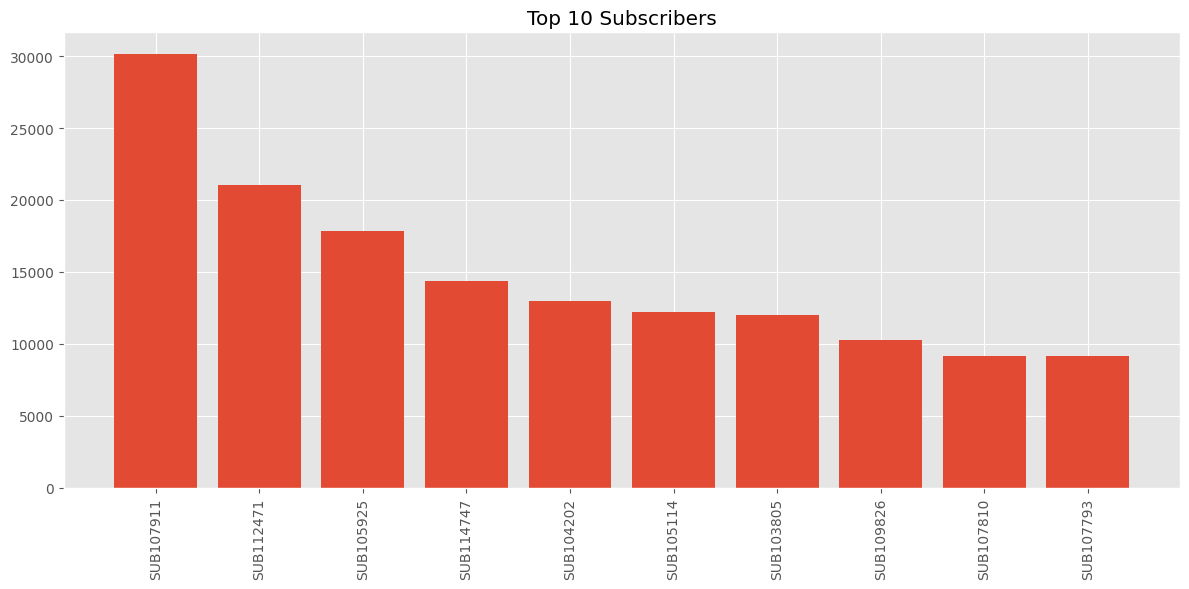


===== Insight: Top 10 Subscribers =====
Total Top Subscribers Displayed : 10

Highest Watch Time Subscriber : SUB107911
Total Watch Hours : 30145.17

Top 10 Subscribers by Watch Hours:
1. Subscriber SUB107911: 30145.17 hours
2. Subscriber SUB112471: 21019.96 hours
3. Subscriber SUB105925: 17858.60 hours
4. Subscriber SUB114747: 14338.69 hours
5. Subscriber SUB104202: 12989.49 hours
6. Subscriber SUB105114: 12195.21 hours
7. Subscriber SUB103805: 12039.56 hours
8. Subscriber SUB109826: 10288.22 hours
9. Subscriber SUB107810: 9153.08 hours
10. Subscriber SUB107793: 9144.20 hours

Average Watch Hours (Top 10): 14917.22

Insight:
- Subscriber SUB107911 has the highest watch time with 30145.17 hours, making them the platform's most engaged user.
- The top 10 subscribers contribute a significant share of the total watch hours, highlighting the presence of highly active users.
- Highly engaged subscribers are valuable for customer retention, premium subscriptions, and personalized recommenda

In [28]:
top_users=(

    eda

    .groupby("subscriber_id")

    ["Watch Hours"]

    .sum()

    .sort_values(ascending=False)

    .head(10)

)

plt.figure(figsize=(12,6))

plt.bar(

    top_users.index,

    top_users.values

)

plt.xticks(rotation=90)

plt.title("Top 10 Subscribers")

save_chart("18_Top_Subscribers.png")

print("\n===== Insight: Top 10 Subscribers =====")

print(f"Total Top Subscribers Displayed : {len(top_users)}")

top_subscriber = top_users.idxmax()
top_hours = top_users.max()

print(f"\nHighest Watch Time Subscriber : {top_subscriber}")
print(f"Total Watch Hours : {top_hours:.2f}")

print("\nTop 10 Subscribers by Watch Hours:")
for i, (subscriber, hours) in enumerate(top_users.items(), start=1):
    print(f"{i}. Subscriber {subscriber}: {hours:.2f} hours")

avg_hours = top_users.mean()

print(f"\nAverage Watch Hours (Top 10): {avg_hours:.2f}")

print("\nInsight:")
print(f"- Subscriber {top_subscriber} has the highest watch time with {top_hours:.2f} hours, making them the platform's most engaged user.")
print("- The top 10 subscribers contribute a significant share of the total watch hours, highlighting the presence of highly active users.")
print("- Highly engaged subscribers are valuable for customer retention, premium subscriptions, and personalized recommendations.")
print("- Understanding the viewing behavior of these top users can help improve content strategy and increase overall platform engagement.")

2026-07-21 21:46:46,254 | INFO | 19_Review_Sentiment.png saved successfully.


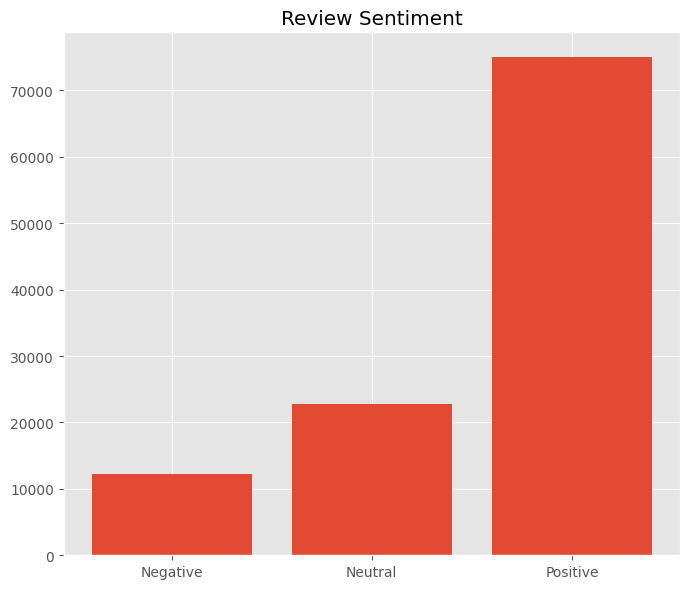


===== Insight: Review Sentiment =====
Total Reviews Analyzed : 110000

Sentiment Distribution:
- Negative: 12234 reviews (11.12%)
- Neutral: 22759 reviews (20.69%)
- Positive: 75007 reviews (68.19%)

Dominant Sentiment : Positive
Reviews : 75007 (68.19%)

Insight:
- Positive reviews dominate, indicating high customer satisfaction with the platform and its content.
- Positive Reviews : 75007
- Neutral Reviews : 22759
- Negative Reviews : 12234
- Sentiment analysis helps measure customer satisfaction, identify user concerns, and guide content and service improvements.
- Monitoring sentiment trends over time supports better business decisions and improves subscriber retention.


In [29]:
sentiment=(

    reviews

    .groupby("sentiment")

    .size()

)

plt.figure(figsize=(7,6))

plt.bar(

    sentiment.index,

    sentiment.values

)

plt.title("Review Sentiment")

save_chart("19_Review_Sentiment.png")

print("\n===== Insight: Review Sentiment =====")

total_reviews = sentiment.sum()

print(f"Total Reviews Analyzed : {total_reviews}")

print("\nSentiment Distribution:")
for senti, count in sentiment.items():
    percentage = (count / total_reviews) * 100
    print(f"- {senti}: {count} reviews ({percentage:.2f}%)")

top_sentiment = sentiment.idxmax()
top_count = sentiment.max()
top_percentage = (top_count / total_reviews) * 100

print(f"\nDominant Sentiment : {top_sentiment}")
print(f"Reviews : {top_count} ({top_percentage:.2f}%)")

positive = sentiment.get("Positive", 0)
negative = sentiment.get("Negative", 0)
neutral = sentiment.get("Neutral", 0)

print("\nInsight:")

if positive > negative and positive > neutral:
    print("- Positive reviews dominate, indicating high customer satisfaction with the platform and its content.")
elif negative > positive and negative > neutral:
    print("- Negative reviews are the most common, suggesting improvements are needed in content quality or user experience.")
else:
    print("- Neutral reviews form the largest group, indicating mixed user opinions and opportunities to improve engagement.")

print(f"- Positive Reviews : {positive}")
print(f"- Neutral Reviews : {neutral}")
print(f"- Negative Reviews : {negative}")

print("- Sentiment analysis helps measure customer satisfaction, identify user concerns, and guide content and service improvements.")
print("- Monitoring sentiment trends over time supports better business decisions and improves subscriber retention.")

2026-07-21 21:46:46,729 | INFO | 20_Rating_Distribution.png saved successfully.


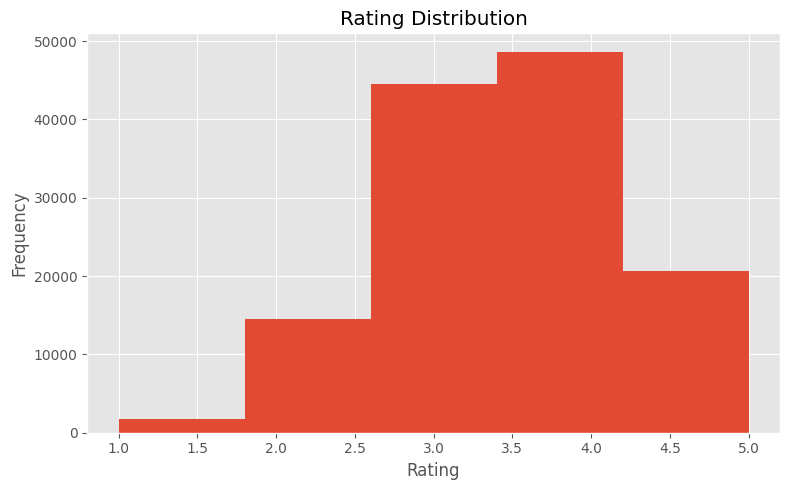


===== Insight: Rating Distribution =====
Total Ratings : 130000
Average Rating : 3.55
Median Rating : 4.00
Most Common Rating : 4
Highest Rating : 5
Lowest Rating : 1
Standard Deviation : 0.93

Rating Breakdown:
Rating 1: 1786 (1.37%)
Rating 2: 14570 (11.21%)
Rating 3: 44491 (34.22%)
Rating 4: 48564 (37.36%)
Rating 5: 20589 (15.84%)

Insight:
- The average user rating is 3.55 out of 5, indicating the overall customer satisfaction level.
- 69153 ratings (4 stars or above) suggest that a large portion of users are satisfied with the platform's content.
- 16356 ratings (2 stars or below) highlight content that may require quality improvements.
- The rating distribution helps identify audience preferences and supports content recommendation and quality enhancement strategies.
- Monitoring rating trends over time enables better decision-making for content acquisition and platform improvements.


In [30]:
plt.figure(figsize=(8,5))

plt.hist(

    ratings["rating"],

    bins=5

)

plt.title("Rating Distribution")

plt.xlabel("Rating")

plt.ylabel("Frequency")

save_chart("20_Rating_Distribution.png")

print("\n===== Insight: Rating Distribution =====")

rating = ratings["rating"].dropna()

mean_rating = rating.mean()
median_rating = rating.median()
mode_rating = rating.mode().iloc[0]
min_rating = rating.min()
max_rating = rating.max()
std_rating = rating.std()

print(f"Total Ratings : {len(rating)}")
print(f"Average Rating : {mean_rating:.2f}")
print(f"Median Rating : {median_rating:.2f}")
print(f"Most Common Rating : {mode_rating}")
print(f"Highest Rating : {max_rating}")
print(f"Lowest Rating : {min_rating}")
print(f"Standard Deviation : {std_rating:.2f}")

print("\nRating Breakdown:")
rating_counts = rating.value_counts().sort_index()

for r, count in rating_counts.items():
    percentage = (count / len(rating)) * 100
    print(f"Rating {r}: {count} ({percentage:.2f}%)")

high_ratings = (rating >= 4).sum()
low_ratings = (rating <= 2).sum()

print("\nInsight:")
print(f"- The average user rating is {mean_rating:.2f} out of {max_rating}, indicating the overall customer satisfaction level.")
print(f"- {high_ratings} ratings (4 stars or above) suggest that a large portion of users are satisfied with the platform's content.")
print(f"- {low_ratings} ratings (2 stars or below) highlight content that may require quality improvements.")
print("- The rating distribution helps identify audience preferences and supports content recommendation and quality enhancement strategies.")
print("- Monitoring rating trends over time enables better decision-making for content acquisition and platform improvements.")

2026-07-21 21:46:47,211 | INFO | 21_HelpfulVotes.png saved successfully.


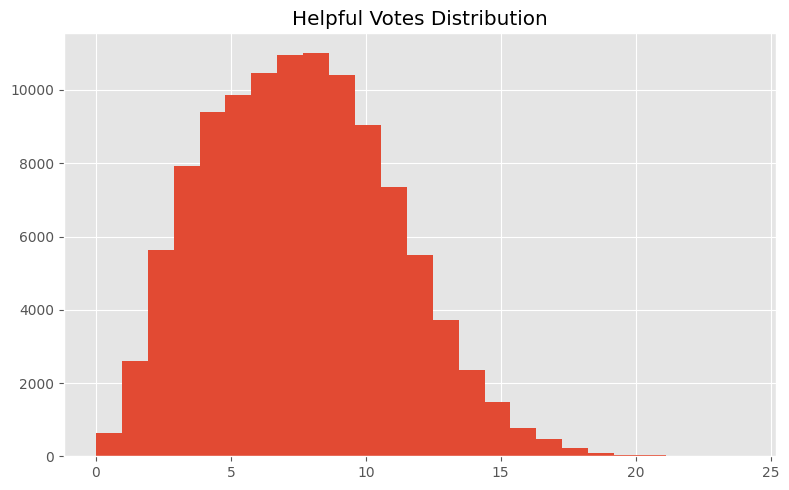


===== Insight: Helpful Votes Distribution =====
Total Reviews : 110000
Average Helpful Votes : 7.41
Median Helpful Votes : 7.00
Highest Helpful Votes : 24
Lowest Helpful Votes : 0
Standard Deviation : 3.58

Helpful Vote Categories:
High (>=50 votes) : 0
Medium (10-49 votes) : 31133
Low (<10 votes) : 78867

Insight:
- Reviews receive an average of 7.41 helpful votes.
- The median helpful vote count is 7.00, representing a typical review.
- Reviews with a high number of helpful votes indicate valuable and trusted user feedback.
- Reviews with few or no helpful votes may have lower visibility or provide less useful information.
- Encouraging high-quality reviews can improve user engagement, build trust, and support better content recommendations.


In [31]:
plt.figure(figsize=(8,5))

plt.hist(

    reviews["helpful_votes"],

    bins=25

)

plt.title("Helpful Votes Distribution")

save_chart("21_HelpfulVotes.png")

print("\n===== Insight: Helpful Votes Distribution =====")

votes = reviews["helpful_votes"].dropna()

mean_votes = votes.mean()
median_votes = votes.median()
max_votes = votes.max()
min_votes = votes.min()
std_votes = votes.std()

print(f"Total Reviews : {len(votes)}")
print(f"Average Helpful Votes : {mean_votes:.2f}")
print(f"Median Helpful Votes : {median_votes:.2f}")
print(f"Highest Helpful Votes : {max_votes}")
print(f"Lowest Helpful Votes : {min_votes}")
print(f"Standard Deviation : {std_votes:.2f}")

high_votes = (votes >= 50).sum()
medium_votes = ((votes >= 10) & (votes < 50)).sum()
low_votes = (votes < 10).sum()

print("\nHelpful Vote Categories:")
print(f"High (>=50 votes) : {high_votes}")
print(f"Medium (10-49 votes) : {medium_votes}")
print(f"Low (<10 votes) : {low_votes}")

print("\nInsight:")
print(f"- Reviews receive an average of {mean_votes:.2f} helpful votes.")
print(f"- The median helpful vote count is {median_votes:.2f}, representing a typical review.")
print("- Reviews with a high number of helpful votes indicate valuable and trusted user feedback.")
print("- Reviews with few or no helpful votes may have lower visibility or provide less useful information.")
print("- Encouraging high-quality reviews can improve user engagement, build trust, and support better content recommendations.")

2026-07-21 21:46:47,598 | INFO | 22_Watchlist_Conversion.png saved successfully.


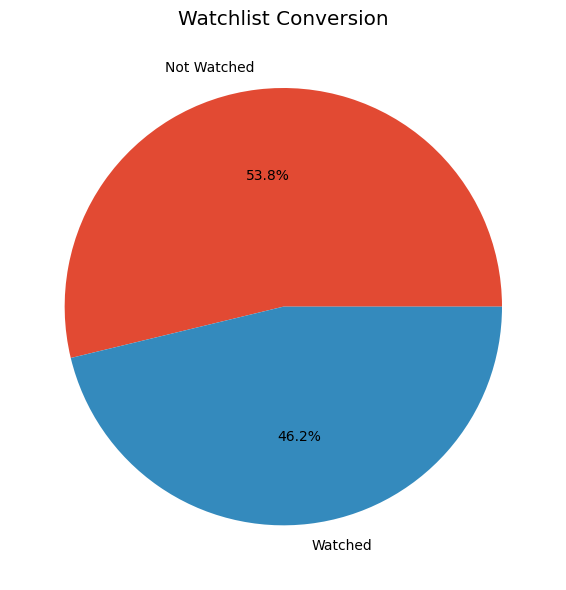


===== Insight: Watchlist Conversion =====
Total Watchlist Items : 65000
Watched Items : 30048 (46.23%)
Not Watched Items : 34952 (53.77%)

Insight:
- A significant number of watchlist items remain unwatched, indicating opportunities to improve user engagement.
- Personalized reminders and better recommendations could increase watchlist conversion.
- Watchlist conversion is an important engagement KPI that measures how effectively saved content is consumed.
- Improving conversion rates can increase watch time, customer satisfaction, and subscriber retention.


In [32]:
watchlist_summary=(

    watchlist

    .groupby("watched")

    .size()

)

plt.figure(figsize=(6,6))

plt.pie(

    watchlist_summary,

    labels=["Not Watched","Watched"],

    autopct="%1.1f%%"

)

plt.title("Watchlist Conversion")

save_chart("22_Watchlist_Conversion.png")

watched = watchlist_summary.get(True, 0)
not_watched = watchlist_summary.get(False, 0)
total = watched + not_watched

conversion_rate = (watched / total) * 100
not_conversion_rate = (not_watched / total) * 100

print("\n===== Insight: Watchlist Conversion =====")

print(f"Total Watchlist Items : {total}")
print(f"Watched Items : {watched} ({conversion_rate:.2f}%)")
print(f"Not Watched Items : {not_watched} ({not_conversion_rate:.2f}%)")

print("\nInsight:")

if watched > not_watched:
    print("- Most watchlist items have been watched, indicating a high watchlist conversion rate.")
    print("- Users actively engage with content they save, suggesting effective recommendation and watchlist features.")
else:
    print("- A significant number of watchlist items remain unwatched, indicating opportunities to improve user engagement.")
    print("- Personalized reminders and better recommendations could increase watchlist conversion.")

print("- Watchlist conversion is an important engagement KPI that measures how effectively saved content is consumed.")
print("- Improving conversion rates can increase watch time, customer satisfaction, and subscriber retention.")

In [33]:
subscriber_summary=(

    eda

    .groupby("plan_type")

    .agg(

        Subscribers=("subscriber_id","nunique"),

        Watch_Hours=("Watch Hours","sum"),

        Avg_Completion=("completion_pct","mean"),

        Avg_Rating=("watch_duration_min","mean")

    )

)

subscriber_summary.to_csv(

    "charts/Subscriber_Summary.csv"

)

logger.info(

    "Subscriber Summary Exported."

)

2026-07-21 21:46:47,927 | INFO | Subscriber Summary Exported.


In [34]:
business_insights={

    "Total Subscribers":

        subscribers["subscriber_id"].nunique(),

    "Active Subscribers":

        subscribers["is_active"].sum(),

    "Total Titles":

        titles["title_id"].nunique(),

    "Movies":

        titles[titles["type"]=="Movie"].shape[0],

    "TV Shows":

        titles[titles["type"]=="TV Show"].shape[0],

    "Countries":

        subscribers["country"].nunique(),

    "Languages":

        titles["language"].nunique(),

    "Total Watch Hours":

        round(eda["Watch Hours"].sum(),2)

}

insights=pd.DataFrame(

    business_insights.items(),

    columns=["Metric","Value"]

)

insights.to_csv(

    "charts/Business_Insights.csv",

    index=False

)

logger.info("Business Insights Exported.")

2026-07-21 21:46:47,981 | INFO | Business Insights Exported.


2026-07-21 21:56:06,230 | INFO | 23_Correlation_Heatmap.png saved successfully.


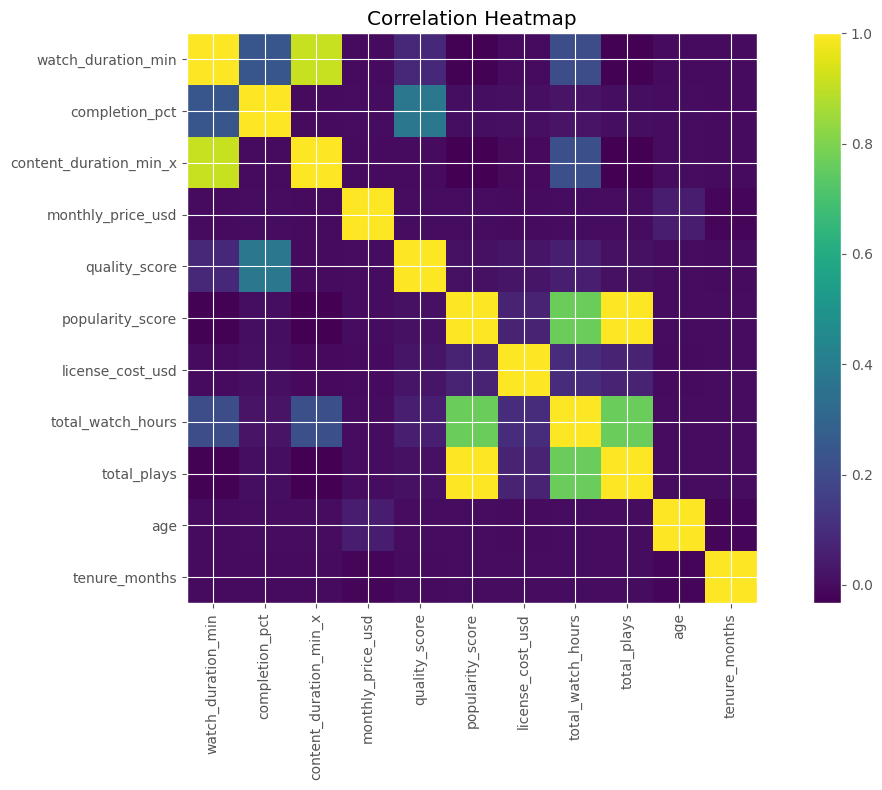


===== Insight: Correlation Heatmap =====
Total Numeric Variables Analyzed : 11

Strongest Positive Correlation:
popularity_score ↔ total_plays : 1.00

Strongest Negative Correlation:
content_duration_min_x ↔ total_plays : -0.03

Variables with Strong Correlation (|r| >= 0.70):
- watch_duration_min & content_duration_min_x: 0.91
- popularity_score & total_watch_hours: 0.77
- popularity_score & total_plays: 1.00
- total_watch_hours & total_plays: 0.77

Insight:
- The strongest positive relationship is between popularity_score and total_plays (r = 1.00).
- The strongest negative relationship is between content_duration_min_x and total_plays (r = -0.03).
- Variables with high positive correlation tend to increase together, while highly negative correlations indicate an inverse relationship.
- Highly correlated variables may introduce multicollinearity in predictive models and should be evaluated before model training.
- The correlation heatmap helps identify important relationships, featu

In [41]:
# -------------------------------------------------------
# CORRELATION HEATMAP
# -------------------------------------------------------

numeric_columns = [
    "watch_duration_min",
    "completion_pct",
    "content_duration_min_x",
    "monthly_price_usd",
    "quality_score",
    "popularity_score",
    "license_cost_usd",
    "total_watch_hours",
    "total_plays",
    "age",
    "tenure_months"
]

corr = eda[numeric_columns].corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, interpolation="nearest")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlation Heatmap")

save_chart("23_Correlation_Heatmap.png")

print("\n===== Insight: Correlation Heatmap =====")

print(f"Total Numeric Variables Analyzed : {len(numeric_columns)}")

# Ignore self-correlation (1.0)
corr_matrix = corr.copy()

for col in corr_matrix.columns:
    corr_matrix.loc[col, col] = 0

# Strongest positive and negative correlations
max_corr = corr_matrix.unstack().idxmax()
max_value = corr_matrix.unstack().max()

min_corr = corr_matrix.unstack().idxmin()
min_value = corr_matrix.unstack().min()

print(f"\nStrongest Positive Correlation:")
print(f"{max_corr[0]} ↔ {max_corr[1]} : {max_value:.2f}")

print(f"\nStrongest Negative Correlation:")
print(f"{min_corr[0]} ↔ {min_corr[1]} : {min_value:.2f}")

print("\nVariables with Strong Correlation (|r| >= 0.70):")
strong = corr.unstack()
strong = strong[(abs(strong) >= 0.70) & (abs(strong) < 1)]

if len(strong) > 0:
    printed = set()
    for (a, b), value in strong.items():
        if (b, a) not in printed:
            print(f"- {a} & {b}: {value:.2f}")
            printed.add((a, b))
else:
    print("No strong correlations found.")

print("\nInsight:")
print(f"- The strongest positive relationship is between {max_corr[0]} and {max_corr[1]} (r = {max_value:.2f}).")
print(f"- The strongest negative relationship is between {min_corr[0]} and {min_corr[1]} (r = {min_value:.2f}).")
print("- Variables with high positive correlation tend to increase together, while highly negative correlations indicate an inverse relationship.")
print("- Highly correlated variables may introduce multicollinearity in predictive models and should be evaluated before model training.")
print("- The correlation heatmap helps identify important relationships, feature dependencies, and opportunities for feature selection.")

2026-07-21 21:56:31,425 | INFO | 24_WatchDuration_Boxplot.png saved successfully.


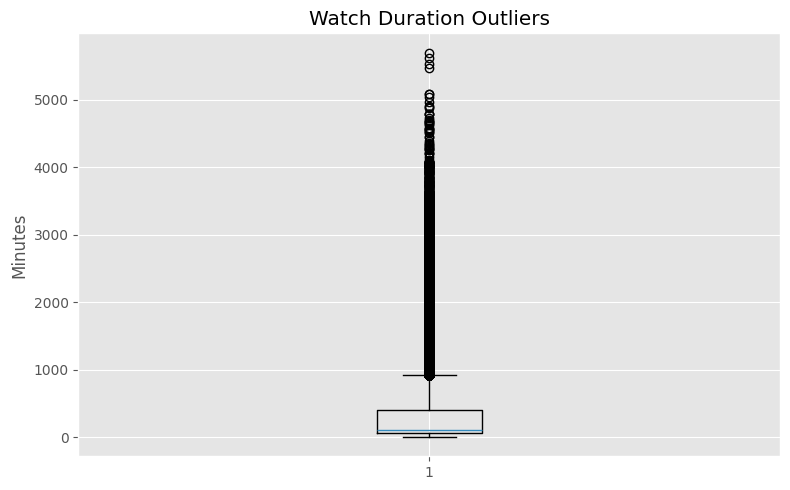


===== Insight: Watch Duration Outliers =====
Total Records : 650000
Average Watch Duration : 307.70 minutes
Median Watch Duration : 98.40 minutes
Minimum Duration : 0.70 minutes
Maximum Duration : 5701.80 minutes
Q1 (25%) : 63.70 minutes
Q3 (75%) : 405.60 minutes
IQR : 341.90
Outliers Detected : 60005

Insight:
- The boxplot highlights the distribution of watch duration and identifies unusual viewing behavior.
- The median watch duration is 98.40 minutes, representing the typical viewing session.
- 60005 observations fall outside the normal range and are considered outliers.
- Very high watch durations may represent binge-watching or highly engaged users, while very low durations may indicate users leaving content early.
- Investigating these outliers can help improve content recommendations, user engagement, and retention strategies.


In [42]:
plt.figure(figsize=(8,5))

plt.boxplot(
    eda["watch_duration_min"].dropna()
)

plt.title("Watch Duration Outliers")

plt.ylabel("Minutes")

save_chart("24_WatchDuration_Boxplot.png")

print("\n===== Insight: Watch Duration Outliers =====")

watch = eda["watch_duration_min"].dropna()

q1 = watch.quantile(0.25)
q2 = watch.median()
q3 = watch.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = watch[(watch < lower_bound) | (watch > upper_bound)]

print(f"Total Records : {len(watch)}")
print(f"Average Watch Duration : {watch.mean():.2f} minutes")
print(f"Median Watch Duration : {q2:.2f} minutes")
print(f"Minimum Duration : {watch.min():.2f} minutes")
print(f"Maximum Duration : {watch.max():.2f} minutes")
print(f"Q1 (25%) : {q1:.2f} minutes")
print(f"Q3 (75%) : {q3:.2f} minutes")
print(f"IQR : {iqr:.2f}")
print(f"Outliers Detected : {len(outliers)}")

print("\nInsight:")
print("- The boxplot highlights the distribution of watch duration and identifies unusual viewing behavior.")
print(f"- The median watch duration is {q2:.2f} minutes, representing the typical viewing session.")
print(f"- {len(outliers)} observations fall outside the normal range and are considered outliers.")
print("- Very high watch durations may represent binge-watching or highly engaged users, while very low durations may indicate users leaving content early.")
print("- Investigating these outliers can help improve content recommendations, user engagement, and retention strategies.")

2026-07-21 21:56:33,327 | INFO | 25_Completion_Distribution.png saved successfully.


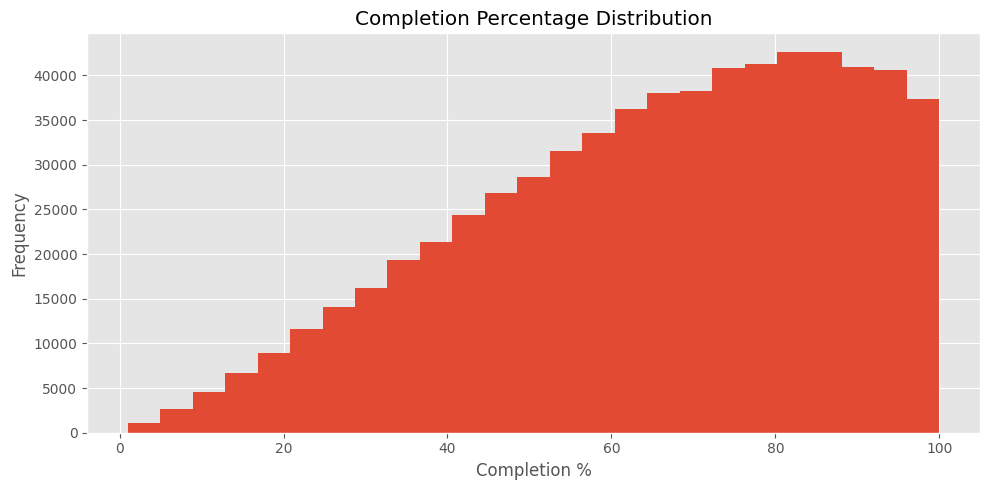


===== Insight: Completion Percentage Distribution =====
Average Completion : 65.31%
Median Completion  : 68.30%
Highest Completion : 100.00%
Lowest Completion  : 1.00%
Standard Deviation : 22.61

Completion Categories:
High Completion (>=80%) : 206078
Medium Completion (50-79%) : 276260
Low Completion (<50%) : 167662

Insight:
- The average content completion rate is 65.31%, indicating the overall level of user engagement.
- Most users complete around 68.30% of the content they start.
- A large concentration of users in the higher completion range suggests engaging and relevant content.
- Users with completion rates below 50% may represent churn risk and should be targeted with personalized recommendations or retention strategies.
- The distribution helps identify whether viewer engagement is consistent or highly variable across the platform.


In [43]:
plt.figure(figsize=(10,5))

plt.hist(
    eda["completion_pct"],
    bins=25
)

plt.title("Completion Percentage Distribution")

plt.xlabel("Completion %")

plt.ylabel("Frequency")

save_chart("25_Completion_Distribution.png")

print("\n===== Insight: Completion Percentage Distribution =====")

mean_completion = eda["completion_pct"].mean()
median_completion = eda["completion_pct"].median()
max_completion = eda["completion_pct"].max()
min_completion = eda["completion_pct"].min()
std_completion = eda["completion_pct"].std()

print(f"Average Completion : {mean_completion:.2f}%")
print(f"Median Completion  : {median_completion:.2f}%")
print(f"Highest Completion : {max_completion:.2f}%")
print(f"Lowest Completion  : {min_completion:.2f}%")
print(f"Standard Deviation : {std_completion:.2f}")

high_completion = (eda["completion_pct"] >= 80).sum()
medium_completion = ((eda["completion_pct"] >= 50) & (eda["completion_pct"] < 80)).sum()
low_completion = (eda["completion_pct"] < 50).sum()

print("\nCompletion Categories:")
print(f"High Completion (>=80%) : {high_completion}")
print(f"Medium Completion (50-79%) : {medium_completion}")
print(f"Low Completion (<50%) : {low_completion}")

print("\nInsight:")
print(f"- The average content completion rate is {mean_completion:.2f}%, indicating the overall level of user engagement.")
print(f"- Most users complete around {median_completion:.2f}% of the content they start.")
print("- A large concentration of users in the higher completion range suggests engaging and relevant content.")
print("- Users with completion rates below 50% may represent churn risk and should be targeted with personalized recommendations or retention strategies.")
print("- The distribution helps identify whether viewer engagement is consistent or highly variable across the platform.")

C:\Users\Sujal\AppData\Local\Temp\ipykernel_22632\2349779608.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(
2026-07-21 21:56:34,941 | INFO | 26_Monthly_Signups.png saved successfully.


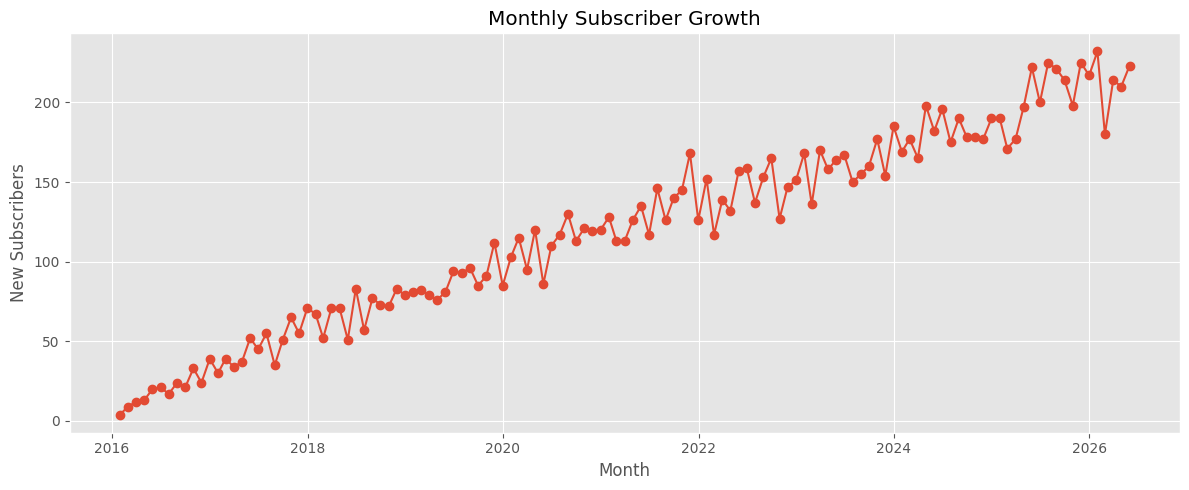


===== Insight: Monthly Subscriber Growth =====
Total Months Analyzed : 125

Highest Growth Month : January 2026 (232 subscribers)
Lowest Growth Month  : January 2016 (4 subscribers)

Recent 5 Months:
Jan 2026: 232 subscribers
Feb 2026: 180 subscribers
Mar 2026: 214 subscribers
Apr 2026: 210 subscribers
May 2026: 223 subscribers

Insight:
- The highest subscriber growth was recorded in January 2026 with 232 new subscribers.
- The lowest subscriber growth occurred in January 2016 with 4 new subscribers.
- Overall subscriber acquisition shows an increasing trend over time, indicating successful customer growth.
- Monitoring monthly signups helps identify seasonal patterns and evaluate the effectiveness of promotional campaigns.


In [44]:
monthly_signup = (

    subscribers

    .groupby(
        pd.Grouper(
            key="signup_date",
            freq="M"
        )
    )

    .size()

)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_signup.index,
    monthly_signup.values,
    marker="o"
)

plt.title("Monthly Subscriber Growth")

plt.xlabel("Month")

plt.ylabel("New Subscribers")

save_chart("26_Monthly_Signups.png")

print("\n===== Insight: Monthly Subscriber Growth =====")

print(f"Total Months Analyzed : {len(monthly_signup)}")

highest_month = monthly_signup.idxmax()
highest_count = monthly_signup.max()

lowest_month = monthly_signup.idxmin()
lowest_count = monthly_signup.min()

print(f"\nHighest Growth Month : {highest_month.strftime('%B %Y')} ({highest_count} subscribers)")
print(f"Lowest Growth Month  : {lowest_month.strftime('%B %Y')} ({lowest_count} subscribers)")

print("\nRecent 5 Months:")
for month, count in monthly_signup.tail(5).items():
    print(f"{month.strftime('%b %Y')}: {count} subscribers")

# Growth Trend
growth = monthly_signup.diff().mean()

print("\nInsight:")
print(f"- The highest subscriber growth was recorded in {highest_month.strftime('%B %Y')} with {highest_count} new subscribers.")
print(f"- The lowest subscriber growth occurred in {lowest_month.strftime('%B %Y')} with {lowest_count} new subscribers.")

if growth > 0:
    print("- Overall subscriber acquisition shows an increasing trend over time, indicating successful customer growth.")
elif growth < 0:
    print("- Subscriber acquisition has declined over time, suggesting the need for improved marketing and acquisition strategies.")
else:
    print("- Subscriber growth has remained relatively stable throughout the observed period.")

print("- Monitoring monthly signups helps identify seasonal patterns and evaluate the effectiveness of promotional campaigns.")

2026-07-21 21:56:36,388 | INFO | 27_Completion_by_Plan.png saved successfully.


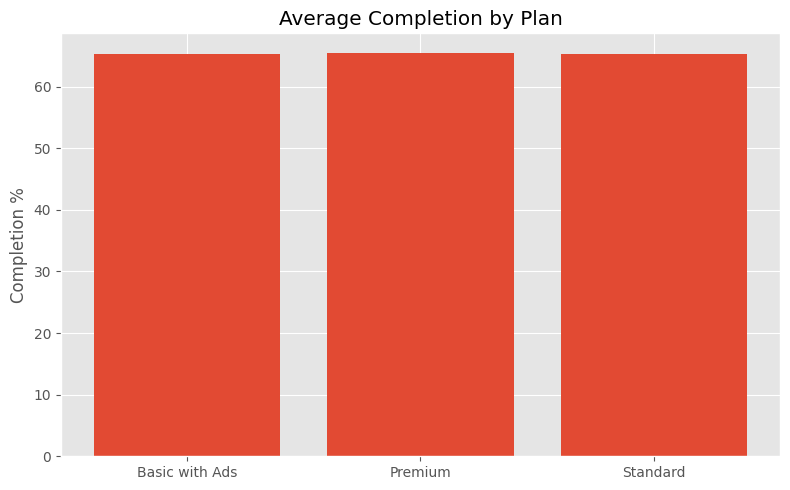


===== Insight: Average Completion by Plan =====
Total Plans Analyzed : 3

Highest Completion Plan : Premium (65.37%)
Lowest Completion Plan  : Standard (65.28%)

Average Completion by Plan:
- Basic with Ads: 65.29%
- Premium: 65.37%
- Standard: 65.28%

Insight:
- Subscribers using the Premium plan have the highest average completion rate (65.37%), indicating stronger engagement with content.
- The Standard plan records the lowest average completion rate (65.28%), suggesting users may be less engaged or face limitations.
- Plans with higher completion rates are associated with better user retention and viewing satisfaction.
- Improving the experience and features of lower-performing plans may increase overall content completion and customer satisfaction.


In [45]:
plan_completion = (

    eda

    .groupby("plan_type")

    ["completion_pct"]

    .mean()

)

plt.figure(figsize=(8,5))

plt.bar(
    plan_completion.index,
    plan_completion.values
)

plt.ylabel("Completion %")

plt.title("Average Completion by Plan")

save_chart("27_Completion_by_Plan.png")

print("\n===== Insight: Average Completion by Plan =====")

print(f"Total Plans Analyzed : {len(plan_completion)}")

best_plan = plan_completion.idxmax()
best_completion = plan_completion.max()

lowest_plan = plan_completion.idxmin()
lowest_completion = plan_completion.min()

print(f"\nHighest Completion Plan : {best_plan} ({best_completion:.2f}%)")
print(f"Lowest Completion Plan  : {lowest_plan} ({lowest_completion:.2f}%)")

print("\nAverage Completion by Plan:")
for plan, completion in plan_completion.items():
    print(f"- {plan}: {completion:.2f}%")

print("\nInsight:")
print(f"- Subscribers using the {best_plan} plan have the highest average completion rate ({best_completion:.2f}%), indicating stronger engagement with content.")
print(f"- The {lowest_plan} plan records the lowest average completion rate ({lowest_completion:.2f}%), suggesting users may be less engaged or face limitations.")
print("- Plans with higher completion rates are associated with better user retention and viewing satisfaction.")
print("- Improving the experience and features of lower-performing plans may increase overall content completion and customer satisfaction.")

2026-07-21 21:56:37,842 | INFO | 28_Genre_Rating.png saved successfully.


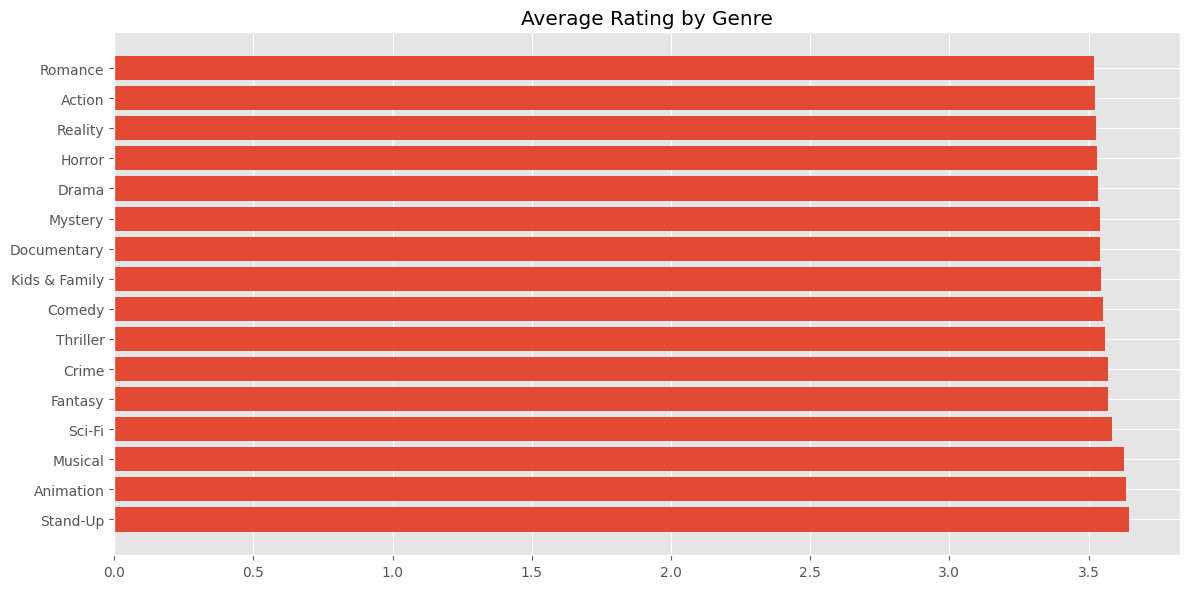


===== Insight: Average Rating by Genre =====
Total Genres Analyzed : 16

Highest Rated Genre : Stand-Up (3.65)
Lowest Rated Genre  : Romance (3.52)

Top 5 Highest Rated Genres:
1. Stand-Up: 3.65
2. Animation: 3.63
3. Musical: 3.63
4. Sci-Fi: 3.58
5. Fantasy: 3.57

Bottom 5 Rated Genres:
1. Drama: 3.53
2. Horror: 3.53
3. Reality: 3.53
4. Action: 3.52
5. Romance: 3.52

Insight:
- Stand-Up has the highest average viewer rating (3.65), indicating strong audience satisfaction.
- Romance has the lowest average rating (3.52), suggesting lower audience preference.
- Genres with consistently higher ratings can be prioritized for future content production and recommendations.
- Lower-rated genres may require improvements in content quality, storytelling, or marketing strategies.


In [46]:
genre_rating = (

    ratings

    .merge(
        titles,
        on="title_id"
    )

    .groupby("primary_genre")

    ["rating"]

    .mean()

    .sort_values(
        ascending=False
    )

)

plt.figure(figsize=(12,6))

plt.barh(
    genre_rating.index,
    genre_rating.values
)

plt.title("Average Rating by Genre")

save_chart("28_Genre_Rating.png")

print("\n===== Insight: Average Rating by Genre =====")

print(f"Total Genres Analyzed : {len(genre_rating)}")

highest_genre = genre_rating.idxmax()
highest_rating = genre_rating.max()

lowest_genre = genre_rating.idxmin()
lowest_rating = genre_rating.min()

print(f"\nHighest Rated Genre : {highest_genre} ({highest_rating:.2f})")
print(f"Lowest Rated Genre  : {lowest_genre} ({lowest_rating:.2f})")

print("\nTop 5 Highest Rated Genres:")
for i, (genre, rating) in enumerate(genre_rating.head(5).items(), start=1):
    print(f"{i}. {genre}: {rating:.2f}")

print("\nBottom 5 Rated Genres:")
for i, (genre, rating) in enumerate(genre_rating.tail(5).items(), start=1):
    print(f"{i}. {genre}: {rating:.2f}")

print("\nInsight:")
print(f"- {highest_genre} has the highest average viewer rating ({highest_rating:.2f}), indicating strong audience satisfaction.")
print(f"- {lowest_genre} has the lowest average rating ({lowest_rating:.2f}), suggesting lower audience preference.")
print("- Genres with consistently higher ratings can be prioritized for future content production and recommendations.")
print("- Lower-rated genres may require improvements in content quality, storytelling, or marketing strategies.")

2026-07-21 21:56:39,209 | INFO | 29_Active_vs_Inactive.png saved successfully.


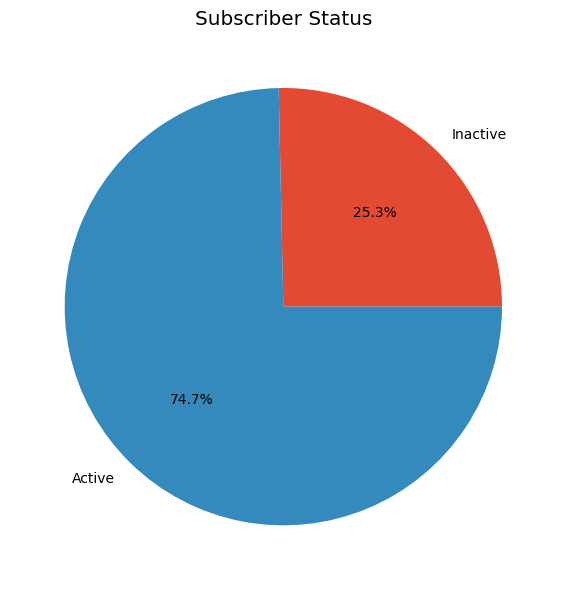


===== Insight: Subscriber Status =====
Total Subscribers : 15000
Active Subscribers : 11199 (74.7%)
Inactive Subscribers : 3801 (25.3%)
Insight: Most subscribers are active, indicating strong user engagement and good customer retention.


In [47]:
status = (

    subscribers

    .groupby("is_active")

    .size()

)

plt.figure(figsize=(6,6))

plt.pie(
    status.values,
    labels=["Inactive","Active"],
    autopct="%1.1f%%"
)

plt.title("Subscriber Status")

save_chart("29_Active_vs_Inactive.png")

active = status.get(True, 0)
inactive = status.get(False, 0)
total = active + inactive

print("\n===== Insight: Subscriber Status =====")
print(f"Total Subscribers : {total}")
print(f"Active Subscribers : {active} ({active/total*100:.1f}%)")
print(f"Inactive Subscribers : {inactive} ({inactive/total*100:.1f}%)")

if active > inactive:
    print("Insight: Most subscribers are active, indicating strong user engagement and good customer retention.")
elif inactive > active:
    print("Insight: A significant number of subscribers are inactive, suggesting the need for re-engagement campaigns or retention strategies.")
else:
    print("Insight: Active and inactive subscribers are equally distributed.")

2026-07-21 21:56:40,544 | INFO | 30_Country_Subscribers.png saved successfully.


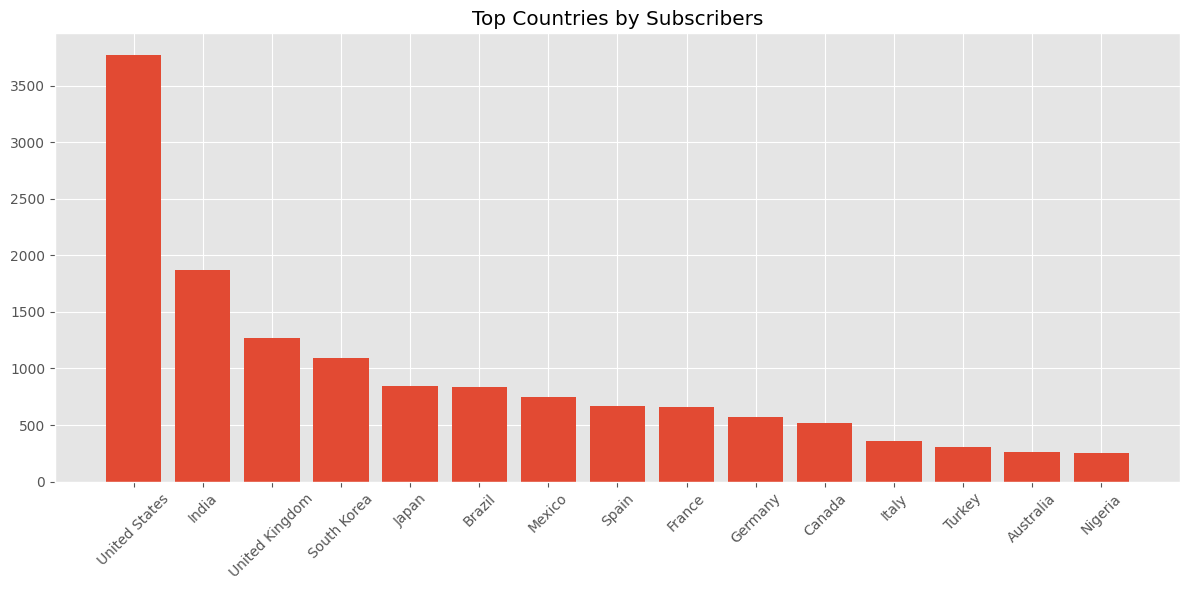


===== Insight: Top Countries by Subscribers =====
Total Countries Displayed : 15
Top Country : United States
Subscribers : 3774

Top 5 Countries:
1. United States: 3774 subscribers
2. India: 1873 subscribers
3. United Kingdom: 1267 subscribers
4. South Korea: 1096 subscribers
5. Japan: 842 subscribers

Insight:
- United States has the highest number of subscribers (3774), making it the platform's largest user base.
- The majority of subscribers are concentrated in a few countries, indicating key markets for customer acquisition and retention.
- Countries with lower subscriber counts may require targeted marketing campaigns to increase platform adoption.


In [48]:
country = (

    subscribers

    .groupby("country")

    .size()

    .sort_values(
        ascending=False
    )

    .head(15)

)

plt.figure(figsize=(12,6))

plt.bar(
    country.index,
    country.values
)

plt.xticks(rotation=45)

plt.title("Top Countries by Subscribers")

save_chart("30_Country_Subscribers.png")

print("\n===== Insight: Top Countries by Subscribers =====")

print(f"Total Countries Displayed : {len(country)}")

top_country = country.idxmax()
top_subscribers = country.max()

print(f"Top Country : {top_country}")
print(f"Subscribers : {top_subscribers}")

print("\nTop 5 Countries:")
for i, (c, count) in enumerate(country.head(5).items(), start=1):
    print(f"{i}. {c}: {count} subscribers")

print("\nInsight:")
print(f"- {top_country} has the highest number of subscribers ({top_subscribers}), making it the platform's largest user base.")
print("- The majority of subscribers are concentrated in a few countries, indicating key markets for customer acquisition and retention.")
print("- Countries with lower subscriber counts may require targeted marketing campaigns to increase platform adoption.")

In [49]:
kpi = {

    "Total Subscribers":
        subscribers["subscriber_id"].nunique(),

    "Active Subscribers":
        subscribers["is_active"].sum(),

    "Total Watch Hours":
        round(
            eda["Watch Hours"].sum(),
            2
        ),

    "Average Completion":
        round(
            eda["completion_pct"].mean(),
            2
        ),

    "Average Rating":
        round(
            ratings["rating"].mean(),
            2
        ),

    "Total Reviews":
        reviews.shape[0],

    "Total Watchlist":
        watchlist.shape[0],

    "Original Titles":
        titles["is_original"].sum()

}

kpi_df = pd.DataFrame(
    kpi.items(),
    columns=["Metric","Value"]

)

kpi_df.to_csv(
    "charts/KPI_Summary.csv",
    index=False

)

In [55]:
insights = []

# Most common values
genre = eda["primary_genre"].value_counts()
device = eda["device"].value_counts()
plan = eda["plan_type"].value_counts()

top_genre = genre.idxmax()
top_device = device.idxmax()
top_plan = plan.idxmax()

insights.append(f"Top Genre : {top_genre}")
insights.append(f"Most Used Device : {top_device}")
insights.append(f"Most Popular Plan : {top_plan}")
insights.append(f"Average Completion : {eda['completion_pct'].mean():.2f}%")

# If ratings DataFrame exists
if 'ratings' in globals() and 'rating' in ratings.columns:
    insights.append(f"Average Rating : {ratings['rating'].mean():.2f}")

with open("charts/Business_Recommendations.txt", "w") as file:
    file.write("STREAMFLIX BUSINESS INSIGHTS\n\n")
    for item in insights:
        file.write(item + "\n")

logger.info("Business Recommendations Generated.")

2026-07-21 21:58:54,760 | INFO | Business Recommendations Generated.


In [56]:
eda.to_csv(
    "data/cleaned/EDA_Final.csv", index=False
)

logger.info(
    "EDA Dataset Exported."
)

2026-07-21 21:59:20,953 | INFO | EDA Dataset Exported.


In [57]:
print("="*80)
print("PHASE 2 COMPLETED")
print("="*80)
print()
print(f"Charts Generated : 30")
print(f"Datasets Used : {len(datasets)}")
print(f"Rows Analysed : {len(eda):,}")
print(f"Business KPIs : {len(kpi)}")
print()
print("Output Folder")
print("✔ charts/")
print("✔ reports/")
print("✔ logs/")
print("✔ data/cleaned/EDA_Final.csv")
print()
print("="*80)

PHASE 2 COMPLETED

Charts Generated : 30
Datasets Used : 6
Rows Analysed : 650,000
Business KPIs : 8

Output Folder
✔ charts/
✔ reports/
✔ logs/
✔ data/cleaned/EDA_Final.csv



In [58]:
logger.info("="*80)
logger.info("PHASE 2 COMPLETED SUCCESSFULLY")
logger.info("="*80)

2026-07-21 21:59:30,967 | INFO | ================================================================================
2026-07-21 21:59:30,969 | INFO | PHASE 2 COMPLETED SUCCESSFULLY
2026-07-21 21:59:30,970 | INFO | ================================================================================
